# PTB-XL ECG First Improvement: SWT Denoising + Beat-Wise Augmentation
## CS437/CS5317/EE414/EE513: Deep Learning, Spring 2026
### Hassan Iftikhar (27100204) | Saim Bilal (27100208)

This notebook implements the **First Improvement** over the baseline pipeline.
We keep the model (ResNet1D) fixed and isolate the effect of two preprocessing changes:

1. **SWT Denoising**: replacing Butterworth with Stationary Wavelet Transform
2. **LBWA Augmentation**: beat-wise time warping + amplitude jitter on minority classes

This forms a **2×2 ablation study**:

Conditions:
- A_butter_noaug
- B_butter_lbwa
- C_swt_noaug
- D_swt_lbwa
- E_raw_no_preprocess (raw + z-score, no filtering, no augmentation)

Shared model/eval core:
- Baseline ResNet1D architecture
- Baseline Grad-CAM logic
- Metrics: Macro-AUC, Macro-F1, per-class AUC, MAS

## 1. Imports

In [1]:
import ast
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import neurokit2 as nk
import numpy as np
import pandas as pd
import pywt
import torch
import wfdb
from scipy.signal import butter, filtfilt, medfilt
from collections import Counter

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyWavelets: {pywt.__version__}")
print(f"NeuroKit2 : {nk.__version__}")
print("Imports ready.")

PyWavelets: 1.8.0
NeuroKit2 : 0.2.13
Imports ready.


In [2]:
# DEVICE = torch.device('cpu')
# print(f"Using device: {DEVICE}")

## 2. Configuration

In [3]:
# Paths
DATA_PATH = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
SAVE_PATH = "/kaggle/working/"
# DATA_PATH = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/first_improvement/ptb-xl/"
# SAVE_PATH = "/mnt/d/lums_nerd_stuff/jnr_spring/CS437/project/first_improvement/save_path/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Signal/lead config
FS = 500
SIGNAL_LEN = 5000
LEAD_INDICES = [0, 1, 6]
LEAD_NAMES = ['I', 'II', 'V1']
N_LEADS = len(LEAD_INDICES)
MORPH_LEAD = 1

# Labels
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
MINORITY = ['MI', 'STTC', 'CD', 'HYP']

# Butterworth control path
BUTTER_LOW = 0.5
BUTTER_HIGH = 40.0
BUTTER_ORDER = 3

# SWT path
SWT_WAVELET = 'db8'
SWT_LEVEL = 8

# LBWA augmentation
AUG_ALPHA = 0.12
AUG_AMP_STD = 0.05
AUG_MAX_RETRIES = 8

# Peak voting
PEAK_VOTE_TOL_MS = 80
PEAK_VOTE_MIN_LEADS = 2
PEAK_MATCH_TOL_MS = 120

# Condition names
RAW_CONDITION_NAME = 'E_raw_no_preprocess'
CONDITION_SPECS = [
    {'name': 'A_butter_noaug', 'use_swt': False, 'use_aug': False, 'use_raw_no_filter': False},
    {'name': 'B_butter_lbwa',  'use_swt': False, 'use_aug': True,  'use_raw_no_filter': False},
    {'name': 'C_swt_noaug',    'use_swt': True,  'use_aug': False, 'use_raw_no_filter': False},
    {'name': 'D_swt_lbwa',     'use_swt': True,  'use_aug': True,  'use_raw_no_filter': False},
    {'name': RAW_CONDITION_NAME, 'use_swt': False, 'use_aug': False, 'use_raw_no_filter': True},
]

assert os.path.exists(DATA_PATH + "ptbxl_database.csv"), "ptbxl_database.csv not found"
assert os.path.exists(DATA_PATH + "scp_statements.csv"), "scp_statements.csv not found"
assert os.path.exists(DATA_PATH + "records500/"), "records500/ not found"

print("Config ready.")
print(f"Leads: {LEAD_NAMES} | Signal: {SIGNAL_LEN} samples @ {FS} Hz")

Config ready.
Leads: ['I', 'II', 'V1'] | Signal: 5000 samples @ 500 Hz


## 3a. Metadata, Labels, and Split

In [4]:
df = pd.read_csv(DATA_PATH + "ptbxl_database.csv", index_col="ecg_id")
scp_df = pd.read_csv(DATA_PATH + "scp_statements.csv", index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]

df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

def get_superclass(scp_codes):
    out = []
    for code, likelihood in scp_codes.items():
        if code in scp_df.index:
            sc = scp_df.loc[code, 'diagnostic_class']
            if pd.notna(sc) and likelihood > 0:
                out.append(sc)
    return list(set(out))

df['superclass'] = df['scp_codes'].apply(get_superclass)
df_filtered = df[df['superclass'].map(len) > 0].copy()

for cls in SUPERCLASSES:
    df_filtered[cls] = df_filtered['superclass'].apply(lambda x: int(cls in x))

train_df = df_filtered[df_filtered['strat_fold'] <= 8].copy()
val_df = df_filtered[df_filtered['strat_fold'] == 9].copy()
test_df = df_filtered[df_filtered['strat_fold'] == 10].copy()

train_pids = set(train_df['patient_id'].unique())
test_pids = set(test_df['patient_id'].unique())
overlap = train_pids & test_pids

print(f"Total labeled records: {len(df_filtered):,}")
print(f"Train/Val/Test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"Patient overlap train-test: {len(overlap)}")

Total labeled records: 21,417
Train/Val/Test: 17,100 / 2,155 / 2,162
Patient overlap train-test: 0


## 3b. Dataset Metrics & Class Distribution

Class Distribution (full labeled dataset):
----------------------------------------
NORM  :  9,528 (44.5%)
MI    :  5,486 (25.6%)
STTC  :  5,123 (23.9%)
CD    :  4,907 (22.9%)
HYP   :  2,655 (12.4%)


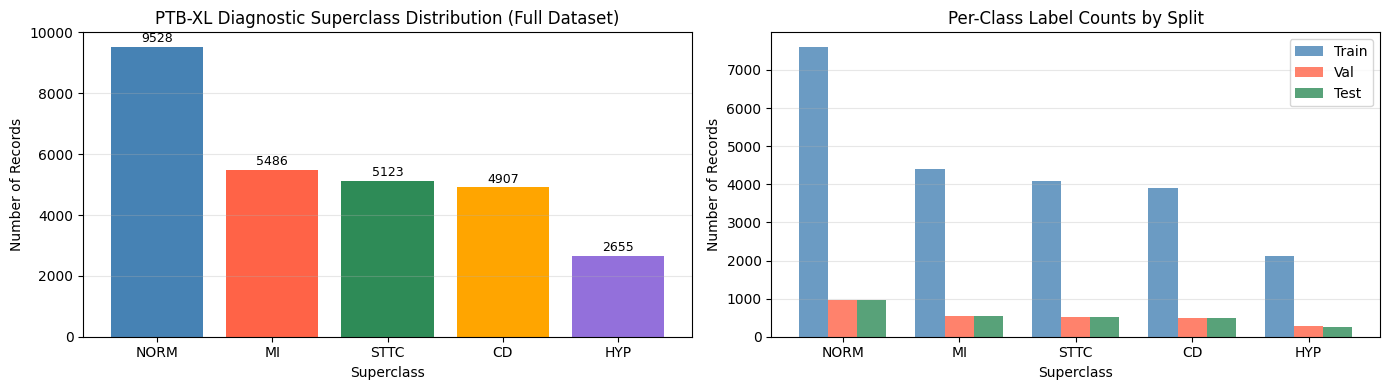


Split sizes:
  Training set   : 17,100 records  (folds 1-8)
  Validation set :  2,155 records  (fold  9)
  Test set       :  2,162 records  (fold 10)
  Patient overlap (train/test): 0  →  No overlap

Class  |    Train    (%) |    Val    (%) |   Test    (%)
-------------------------------------------------------
NORM   |    7,607  44.5% |    957  44.4% |    964  44.6%
MI     |    4,389  25.7% |    544  25.2% |    553  25.6%
STTC   |    4,094  23.9% |    521  24.2% |    508  23.5%
CD     |    3,912  22.9% |    497  23.1% |    498  23.0%
HYP    |    2,121  12.4% |    271  12.6% |    263  12.2%


In [5]:
all_labels=[lbl for sub in df_filtered['superclass'] for lbl in sub]
label_counts=Counter(all_labels)

print("Class Distribution (full labeled dataset):")
print("-" * 40)
for cls in SUPERCLASSES:
    cnt=label_counts.get(cls, 0)
    pct=cnt/len(df_filtered)*100
    print(f"{cls:<6}: {cnt:>6,} ({pct:.1f}%)")

fig,axes=plt.subplots(1,2,figsize=(14,4))

# the overall bar chart
colors=['steelblue','tomato','seagreen','orange','mediumpurple']
counts_ordered=[label_counts.get(c,0) for c in SUPERCLASSES]
bars=axes[0].bar(SUPERCLASSES,counts_ordered,color=colors)
for bar,cnt in zip(bars,counts_ordered):
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+50,
                 str(cnt),ha='center',va='bottom',fontsize=9)
axes[0].set_title("PTB-XL Diagnostic Superclass Distribution (Full Dataset)")
axes[0].set_xlabel("Superclass")
axes[0].set_ylabel("Number of Records")
axes[0].grid(True,axis='y',alpha=0.3)

# the grouped bar chart per split
width=0.25
x=range(len(SUPERCLASSES))
split_colors=['steelblue','tomato','seagreen']
for (split_df,label,color,offset) in [
    (train_df,'Train','steelblue',-width),
    (val_df,'Val','tomato',0),
    (test_df,'Test','seagreen',width),
]:
    counts=[int(split_df[c].sum()) for c in SUPERCLASSES]
    axes[1].bar([xi+offset for xi in x],counts,width=width,
                label=label,color=color,alpha=0.8)
axes[1].set_title("Per-Class Label Counts by Split")
axes[1].set_xlabel("Superclass")
axes[1].set_ylabel("Number of Records")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(SUPERCLASSES)
axes[1].legend()
axes[1].grid(True,axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

# splitting sizes + patient overlap 
print(f"\nSplit sizes:")
print(f"  Training set   : {len(train_df):>6,} records  (folds 1-8)")
print(f"  Validation set : {len(val_df):>6,} records  (fold  9)")
print(f"  Test set       : {len(test_df):>6,} records  (fold 10)")
overlap_status = 'No overlap' if len(overlap)==0 else f'⚠ {len(overlap)} patients shared!'
print(f"  Patient overlap (train/test): {len(overlap)}  →  {overlap_status}")

# Per-split per-class label counts 
print()
print(f"{'Class':<6} | {'Train':>8} {'(%)':>6} | {'Val':>6} {'(%)':>6} | {'Test':>6} {'(%)':>6}")
print("-" * 55)
for cls in SUPERCLASSES:
    tr_cnt=int(train_df[cls].sum())
    vl_cnt=int(val_df[cls].sum())
    te_cnt=int(test_df[cls].sum())
    tr_pct=tr_cnt/len(train_df)*100
    vl_pct=vl_cnt/len(val_df)*100
    te_pct=te_cnt/len(test_df)*100
    print(f"{cls:<6} | {tr_cnt:>8,} {tr_pct:>5.1f}% | {vl_cnt:>6,} {vl_pct:>5.1f}% | {te_cnt:>6,} {te_pct:>5.1f}%")

## 3c. Morphological Fidelity Check — Butterworth vs SWT
We compare both filters on 3 criteria across 10 samples per class (50 total):
1. **R-peak shift**: how much do R-peak positions move after filtering? (threshold < 1 sample)
2. **P-wave amplitude retention**: how much of the P-wave amplitude is preserved? (threshold > 95%)
3. **R-peak sharpness**: is the R-peak still sharp after filtering? (threshold > 90%)

In [6]:
def zscore(signal_1d):
    return (signal_1d - signal_1d.mean()) / (signal_1d.std() + 1e-8)


def butterworth_filter(signal):
    nyq = 0.5 * FS
    b, a = butter(BUTTER_ORDER, [BUTTER_LOW / nyq, BUTTER_HIGH / nyq], btype='band')
    return filtfilt(b, a, signal)


def swt_filter(signal):
    target_len = int(2 ** SWT_LEVEL * np.ceil(len(signal) / (2 ** SWT_LEVEL)))
    padded = np.pad(signal, (0, target_len - len(signal)), mode='edge')

    coeffs = pywt.swt(padded, wavelet=SWT_WAVELET, level=SWT_LEVEL)

    cA_top, cD_top = coeffs[0]
    coeffs[0] = (np.zeros_like(cA_top), cD_top)

    cA_low, cD_low = coeffs[SWT_LEVEL - 1]
    sigma = np.median(np.abs(cD_low)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(cD_low)))
    coeffs[SWT_LEVEL - 1] = (cA_low, pywt.threshold(cD_low, threshold, mode='soft'))

    rec = pywt.iswt(coeffs, wavelet=SWT_WAVELET)
    return rec[:len(signal)]


def filter_signal(signal, use_swt=False):
    if use_swt:
        return swt_filter(signal)
    return butterworth_filter(signal)


def load_record(row):
    record = wfdb.rdrecord(DATA_PATH + row['filename_hr'])
    return record.p_signal[:, LEAD_INDICES].T.astype(np.float32)


def preprocess_record(row, use_swt=False):
    raw = load_record(row)
    out = np.empty_like(raw, dtype=np.float32)
    for i in range(N_LEADS):
        out[i] = zscore(filter_signal(raw[i], use_swt=use_swt))
    return out

print("Core signal pipeline ready.")

Core signal pipeline ready.


In [7]:
def get_r_peaks_simple(signal):
    try:
        cleaned = nk.ecg_clean(signal, sampling_rate=FS)
        _, info = nk.ecg_peaks(cleaned, sampling_rate=FS)
        return np.array(info['ECG_R_Peaks'])
    except:
        return np.array([])

def r_peak_shift(raw, filtered):
    raw_peaks      = get_r_peaks_simple(raw)
    filtered_peaks = get_r_peaks_simple(filtered)
    n = min(len(raw_peaks), len(filtered_peaks))
    if n == 0:
        return np.nan
    return np.mean(np.abs(raw_peaks[:n] - filtered_peaks[:n]))

def p_wave_amplitude_retention(raw, filtered):
    peaks = get_r_peaks_simple(raw)
    if len(peaks) == 0:
        return np.nan
    raw_amps, filt_amps = [], []
    for r in peaks:
        start = r - int(0.20 * FS)
        end   = r - int(0.08 * FS)
        if start < 0:
            continue
        raw_amps.append(np.mean(np.abs(raw[start:end])))
        filt_amps.append(np.mean(np.abs(filtered[start:end])))
    if len(raw_amps) == 0:
        return np.nan
    raw_mean  = np.mean(raw_amps)
    filt_mean = np.mean(filt_amps)
    if raw_mean == 0:
        return np.nan
    return (filt_mean / raw_mean) * 100

def r_peak_sharpness(raw, filtered):
    peaks = get_r_peaks_simple(raw)
    if len(peaks) == 0:
        return np.nan
    raw_sharp, filt_sharp = [], []
    for r in peaks:
        start = max(0, r - 2)
        end   = min(len(raw), r + 3)
        raw_sharp.append(np.max(np.abs(np.diff(raw[start:end]))))
        filt_sharp.append(np.max(np.abs(np.diff(filtered[start:end]))))
    raw_mean  = np.mean(raw_sharp)
    filt_mean = np.mean(filt_sharp)
    if raw_mean == 0:
        return np.nan
    return (filt_mean / raw_mean) * 100

# ── Run on 10 samples per class ───────────────────────────────────────────────
N_FIDELITY = 10
fidelity_results = []

for cls in SUPERCLASSES:
    cls_records = df_filtered[
        df_filtered['superclass'].apply(lambda x: cls in x)
    ].head(N_FIDELITY)

    for _, row in cls_records.iterrows():
        raw_3lead = load_record(row)
        raw       = raw_3lead[MORPH_LEAD]

        # butterworth path
        butter_sig = butterworth_filter(raw)
        # swt path
        swt_sig    = swt_filter(raw)

        fidelity_results.append({
            'class'              : cls,
            'butter_rpeak_shift' : r_peak_shift(raw, butter_sig),
            'butter_pwave_ret'   : p_wave_amplitude_retention(raw, butter_sig),
            'butter_sharpness'   : r_peak_sharpness(raw, butter_sig),
            'swt_rpeak_shift'    : r_peak_shift(raw, swt_sig),
            'swt_pwave_ret'      : p_wave_amplitude_retention(raw, swt_sig),
            'swt_sharpness'      : r_peak_sharpness(raw, swt_sig),
        })

fidelity_df = pd.DataFrame(fidelity_results)

# ── Print table ───────────────────────────────────────────────────────────────
print("=" * 70)
print(f"{'Class':<6} | {'Butterworth':^28} | {'SWT':^28}")
print(f"{'':6} | {'R-shift':>8} {'P-ret%':>8} {'Sharp%':>8} | {'R-shift':>8} {'P-ret%':>8} {'Sharp%':>8}")
print("=" * 70)

for cls in SUPERCLASSES:
    sub = fidelity_df[fidelity_df['class'] == cls]
    print(f"{cls:<6} | "
          f"{sub['butter_rpeak_shift'].mean():>8.2f} "
          f"{sub['butter_pwave_ret'].mean():>8.1f} "
          f"{sub['butter_sharpness'].mean():>8.1f} | "
          f"{sub['swt_rpeak_shift'].mean():>8.2f} "
          f"{sub['swt_pwave_ret'].mean():>8.1f} "
          f"{sub['swt_sharpness'].mean():>8.1f}")

print("=" * 70)
print(f"{'MEAN':<6} | "
      f"{fidelity_df['butter_rpeak_shift'].mean():>8.2f} "
      f"{fidelity_df['butter_pwave_ret'].mean():>8.1f} "
      f"{fidelity_df['butter_sharpness'].mean():>8.1f} | "
      f"{fidelity_df['swt_rpeak_shift'].mean():>8.2f} "
      f"{fidelity_df['swt_pwave_ret'].mean():>8.1f} "
      f"{fidelity_df['swt_sharpness'].mean():>8.1f}")
print()
print("Thresholds: R-shift < 1 sample | P-ret > 95% | Sharpness > 90%")

Class  |         Butterworth          |             SWT             
       |  R-shift   P-ret%   Sharp% |  R-shift   P-ret%   Sharp%
NORM   |     0.08     54.3     62.7 |     0.03     52.6     96.4
MI     |     0.18     61.8     60.4 |     0.06     58.2     96.2
STTC   |     0.10     68.3     77.3 |     0.00     67.7     96.5
CD     |     0.17     63.9     59.9 |     0.03     61.7     98.1
HYP    |     0.10     65.8     67.6 |     0.03     66.5     98.2
MEAN   |     0.13     62.8     65.6 |     0.03     61.3     97.1

Thresholds: R-shift < 1 sample | P-ret > 95% | Sharpness > 90%


## 4a. Core Signal Pipeline (Filters, Masks, Augmentation)

In [8]:
def zscore(signal_1d):
    return (signal_1d - signal_1d.mean()) / (signal_1d.std() + 1e-8)


def butterworth_filter(signal):
    nyq = 0.5 * FS
    b, a = butter(BUTTER_ORDER, [BUTTER_LOW / nyq, BUTTER_HIGH / nyq], btype='band')
    return filtfilt(b, a, signal)


def swt_filter(signal):
    target_len = int(2 ** SWT_LEVEL * np.ceil(len(signal) / (2 ** SWT_LEVEL)))
    padded = np.pad(signal, (0, target_len - len(signal)), mode='edge')

    coeffs = pywt.swt(padded, wavelet=SWT_WAVELET, level=SWT_LEVEL)

    # Level SWT_LEVEL approximation holds baseline wander; zero it out.
    cA_top, cD_top = coeffs[0]
    coeffs[0] = (np.zeros_like(cA_top), cD_top)

    # Level 1 detail keeps most high-frequency noise; soft-threshold it.
    cA_low, cD_low = coeffs[SWT_LEVEL - 1]
    sigma = np.median(np.abs(cD_low)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(cD_low)))
    coeffs[SWT_LEVEL - 1] = (cA_low, pywt.threshold(cD_low, threshold, mode='soft'))

    rec = pywt.iswt(coeffs, wavelet=SWT_WAVELET)
    return rec[:len(signal)]


def filter_signal(signal, use_swt=False):
    if use_swt:
        return swt_filter(signal)
    return butterworth_filter(signal)


def load_record(row):
    record = wfdb.rdrecord(DATA_PATH + row['filename_hr'])
    return record.p_signal[:, LEAD_INDICES].T.astype(np.float32)


def preprocess_record(row, use_swt=False):
    raw = load_record(row)
    out = np.empty_like(raw, dtype=np.float32)
    for i in range(N_LEADS):
        out[i] = zscore(filter_signal(raw[i], use_swt=use_swt)).astype(np.float32)
    return out


def preprocess_record_raw_zscore(row):
    raw = load_record(row)
    out = np.empty_like(raw, dtype=np.float32)
    for i in range(N_LEADS):
        out[i] = zscore(raw[i]).astype(np.float32)
    return out


def get_label(row):
    return np.array([row[c] for c in SUPERCLASSES], dtype=np.float32)


def clean_peak_array(peaks, signal_len=SIGNAL_LEN):
    if peaks is None:
        return np.array([], dtype=int)
    arr = np.asarray(peaks, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]
    arr = arr[(arr >= 0) & (arr < signal_len)]
    if arr.size == 0:
        return np.array([], dtype=int)
    return np.unique(arr.astype(int))


def detect_r_peaks_1lead(signal_1d):
    try:
        cleaned = nk.ecg_clean(signal_1d, sampling_rate=FS)
        _, info = nk.ecg_peaks(cleaned, sampling_rate=FS)
        return clean_peak_array(info.get('ECG_R_Peaks', []), signal_len=len(signal_1d))
    except Exception:
        return np.array([], dtype=int)


def vote_r_peaks_multilead(signal_3lead, tol_ms=PEAK_VOTE_TOL_MS, min_votes=PEAK_VOTE_MIN_LEADS):
    tol = max(1, int(round(tol_ms * FS / 1000.0)))
    lead_peaks = [detect_r_peaks_1lead(signal_3lead[i]) for i in range(signal_3lead.shape[0])]

    pooled = []
    for lead_id, peaks in enumerate(lead_peaks):
        for p in peaks:
            pooled.append((int(p), lead_id))
    if not pooled:
        return np.array([], dtype=int)

    pooled.sort(key=lambda x: x[0])
    clusters = []
    cur = [pooled[0]]
    for peak, lead_id in pooled[1:]:
        if peak - cur[-1][0] <= tol:
            cur.append((peak, lead_id))
        else:
            clusters.append(cur)
            cur = [(peak, lead_id)]
    clusters.append(cur)

    voted = []
    for cl in clusters:
        if len({lead for _, lead in cl}) >= min_votes:
            voted.append(int(round(np.median([p for p, _ in cl]))))

    if not voted:
        voted = detect_r_peaks_1lead(signal_3lead[MORPH_LEAD]).tolist()

    voted = np.array(sorted(voted), dtype=int)
    if voted.size <= 1:
        return voted

    merged = [int(voted[0])]
    for p in voted[1:]:
        if p - merged[-1] <= tol:
            merged[-1] = int(round((merged[-1] + p) / 2.0))
        else:
            merged.append(int(p))
    return np.array(merged, dtype=int)


def mean_abs_peak_shift(ref_peaks, test_peaks, max_tol_ms=PEAK_MATCH_TOL_MS):
    ref_peaks = clean_peak_array(ref_peaks)
    test_peaks = clean_peak_array(test_peaks)
    if len(ref_peaks) == 0 or len(test_peaks) == 0:
        return np.nan

    max_tol = max(1, int(round(max_tol_ms * FS / 1000.0)))
    shifts = []
    j = 0
    for rp in ref_peaks:
        while j + 1 < len(test_peaks) and abs(test_peaks[j + 1] - rp) <= abs(test_peaks[j] - rp):
            j += 1
        d = abs(test_peaks[j] - rp)
        if d <= max_tol:
            shifts.append(d)
    if len(shifts) == 0:
        return np.nan
    return float(np.mean(shifts))


def _safe_index(v, signal_len):
    try:
        if v is None:
            return None
        x = float(v)
        if np.isnan(x):
            return None
        i = int(round(x))
        if i < 0 or i >= signal_len:
            return None
        return i
    except Exception:
        return None


def _fill_mask_from_pairs(mask, onsets, offsets, centers=None, half_width=10):
    n = max(len(onsets), len(offsets), len(centers) if centers is not None else 0)
    for i in range(n):
        on = _safe_index(onsets[i], len(mask)) if i < len(onsets) else None
        off = _safe_index(offsets[i], len(mask)) if i < len(offsets) else None
        center = _safe_index(centers[i], len(mask)) if centers is not None and i < len(centers) else None

        if on is None and center is not None:
            on = center - half_width
        if off is None and center is not None:
            off = center + half_width
        if on is None or off is None:
            continue

        lo = max(0, min(on, off))
        hi = min(len(mask) - 1, max(on, off))
        mask[lo:hi + 1] = True


def extract_boundaries_multilead(signal_3lead):
    lead_signal = signal_3lead[MORPH_LEAD]
    cleaned = nk.ecg_clean(lead_signal, sampling_rate=FS)

    voted_peaks = vote_r_peaks_multilead(signal_3lead)
    if len(voted_peaks) == 0:
        voted_peaks = detect_r_peaks_1lead(lead_signal)
    if len(voted_peaks) == 0:
        return None

    try:
        _, waves = nk.ecg_delineate(cleaned, voted_peaks, sampling_rate=FS, method='dwt')
    except Exception:
        return None

    return {
        'r_peaks': np.array(voted_peaks, dtype=int),
        'p_onsets': np.asarray(waves.get('ECG_P_Onsets', []), dtype=float),
        'p_offsets': np.asarray(waves.get('ECG_P_Offsets', []), dtype=float),
        'qrs_onsets': np.asarray(waves.get('ECG_R_Onsets', []), dtype=float),
        'qrs_offsets': np.asarray(waves.get('ECG_R_Offsets', []), dtype=float),
        't_onsets': np.asarray(waves.get('ECG_T_Onsets', []), dtype=float),
        't_offsets': np.asarray(waves.get('ECG_T_Offsets', []), dtype=float),
    }


def build_binary_mask_from_boundaries(boundaries, signal_len=SIGNAL_LEN):
    mask = np.zeros(signal_len, dtype=np.float32)
    if boundaries is None:
        return mask

    r = boundaries['r_peaks']
    _fill_mask_from_pairs(mask, boundaries['p_onsets'], boundaries['p_offsets'], centers=r, half_width=int(0.04 * FS))
    _fill_mask_from_pairs(mask, boundaries['qrs_onsets'], boundaries['qrs_offsets'], centers=r, half_width=int(0.02 * FS))
    _fill_mask_from_pairs(mask, boundaries['t_onsets'], boundaries['t_offsets'], centers=r, half_width=int(0.08 * FS))
    return mask


def build_mask_for_record(signal_3lead):
    boundaries = extract_boundaries_multilead(signal_3lead)
    mask = build_binary_mask_from_boundaries(boundaries, signal_len=signal_3lead.shape[1])
    return mask, boundaries


def warp_segment_same_length(segment, warp_factor):
    n = len(segment)
    if n < 4 or abs(warp_factor - 1.0) < 1e-8:
        return segment.copy()

    # Notebook569 LBWA warp: resample to warped length, then resample back.
    new_len = max(4, int(round(n * warp_factor)))
    x_old = np.linspace(0.0, 1.0, n, dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, new_len, dtype=np.float32)
    x_back = np.linspace(0.0, 1.0, n, dtype=np.float32)
    warped = np.interp(x_back, x_new, np.interp(x_new, x_old, segment))
    return warped.astype(np.float32)


def warp_indices_in_segment(indices, start, end, warp_factor):
    arr = np.asarray(indices, dtype=float).copy()
    seg_len = end - start
    if seg_len < 4:
        return arr

    center = 0.5 * (seg_len - 1)
    for i in range(len(arr)):
        idx = arr[i]
        if not np.isfinite(idx):
            continue
        idx_int = int(round(idx))
        if idx_int < start or idx_int >= end:
            continue
        local = idx_int - start
        warped_local = center + warp_factor * (local - center)
        warped_local = int(np.clip(np.round(warped_local), 0, seg_len - 1))
        arr[i] = float(start + warped_local)
    return arr


def apply_piecewise_warp_to_indices(indices, transforms):
    warped = np.asarray(indices, dtype=float).copy()
    for tf in transforms:
        warped = warp_indices_in_segment(warped, tf['start'], tf['end'], tf['warp'])
    return warped


def augment_three_leads_and_mask(signal_3lead, mask_1d, boundaries=None):
    peaks = detect_r_peaks_1lead(signal_3lead[MORPH_LEAD])
    if len(peaks) < 2:
        return signal_3lead.copy(), mask_1d.copy(), boundaries

    augmented = signal_3lead.copy()
    aug_mask = mask_1d.copy()
    transforms = []

    for i in range(len(peaks) - 1):
        start = int(peaks[i])
        end = int(peaks[i + 1])
        seg_len = end - start
        if seg_len < 4:
            continue

        warp_factor = 1.0 + np.random.uniform(-AUG_ALPHA, AUG_ALPHA)
        amp_factor = 1.0 + np.random.normal(0, AUG_AMP_STD)
        transforms.append({'start': start, 'end': end, 'warp': warp_factor, 'amp': amp_factor})

        for lead in range(N_LEADS):
            seg = signal_3lead[lead, start:end]
            warped_seg = warp_segment_same_length(seg, warp_factor)
            augmented[lead, start:end] = warped_seg * amp_factor

        mask_seg = mask_1d[start:end].astype(np.float32)
        warped_mask_seg = warp_segment_same_length(mask_seg, warp_factor)
        aug_mask[start:end] = (warped_mask_seg >= 0.5).astype(np.float32)

    aug_boundaries = None
    if boundaries is not None:
        aug_boundaries = {}
        for key, values in boundaries.items():
            arr = np.asarray(values, dtype=float)
            warped_arr = apply_piecewise_warp_to_indices(arr, transforms)
            if key == 'r_peaks':
                aug_boundaries[key] = clean_peak_array(warped_arr, signal_len=signal_3lead.shape[1])
            else:
                aug_boundaries[key] = warped_arr

    return augmented.astype(np.float32), aug_mask.astype(np.float32), aug_boundaries


def passes_fidelity_gate(original_3lead, augmented_3lead):
    orig_peaks = detect_r_peaks_1lead(original_3lead[MORPH_LEAD])
    aug_peaks = detect_r_peaks_1lead(augmented_3lead[MORPH_LEAD])
    if len(orig_peaks) == 0 or len(aug_peaks) == 0:
        return False

    # R-peak detectors can miss/add one beat after mild warping; do not over-penalize.
    if abs(len(orig_peaks) - len(aug_peaks)) > 1:
        return False

    # Use nearest-neighbor matching instead of index-wise pairing for stable shift estimates.
    shift = mean_abs_peak_shift(orig_peaks, aug_peaks, max_tol_ms=PEAK_MATCH_TOL_MS)
    return np.isfinite(shift) and shift <= 4.0


def augment_with_fidelity_retry(signal_3lead, mask_1d, boundaries=None, max_retries=AUG_MAX_RETRIES):
    last_aug = signal_3lead.copy()
    last_mask = mask_1d.copy()
    last_boundaries = boundaries

    for attempt in range(1, max_retries + 1):
        aug_x, aug_m, aug_b = augment_three_leads_and_mask(signal_3lead, mask_1d, boundaries=boundaries)
        if passes_fidelity_gate(signal_3lead, aug_x):
            return aug_x, aug_m, aug_b, True, attempt
        last_aug, last_mask, last_boundaries = aug_x, aug_m, aug_b

    return last_aug, last_mask, last_boundaries, False, max_retries


print("Core signal pipeline ready.")

Core signal pipeline ready.


## 4b. Signal Visualizations
### 4b.1 Raw vs Butterworth vs SWT — Lead II, First 3 Seconds

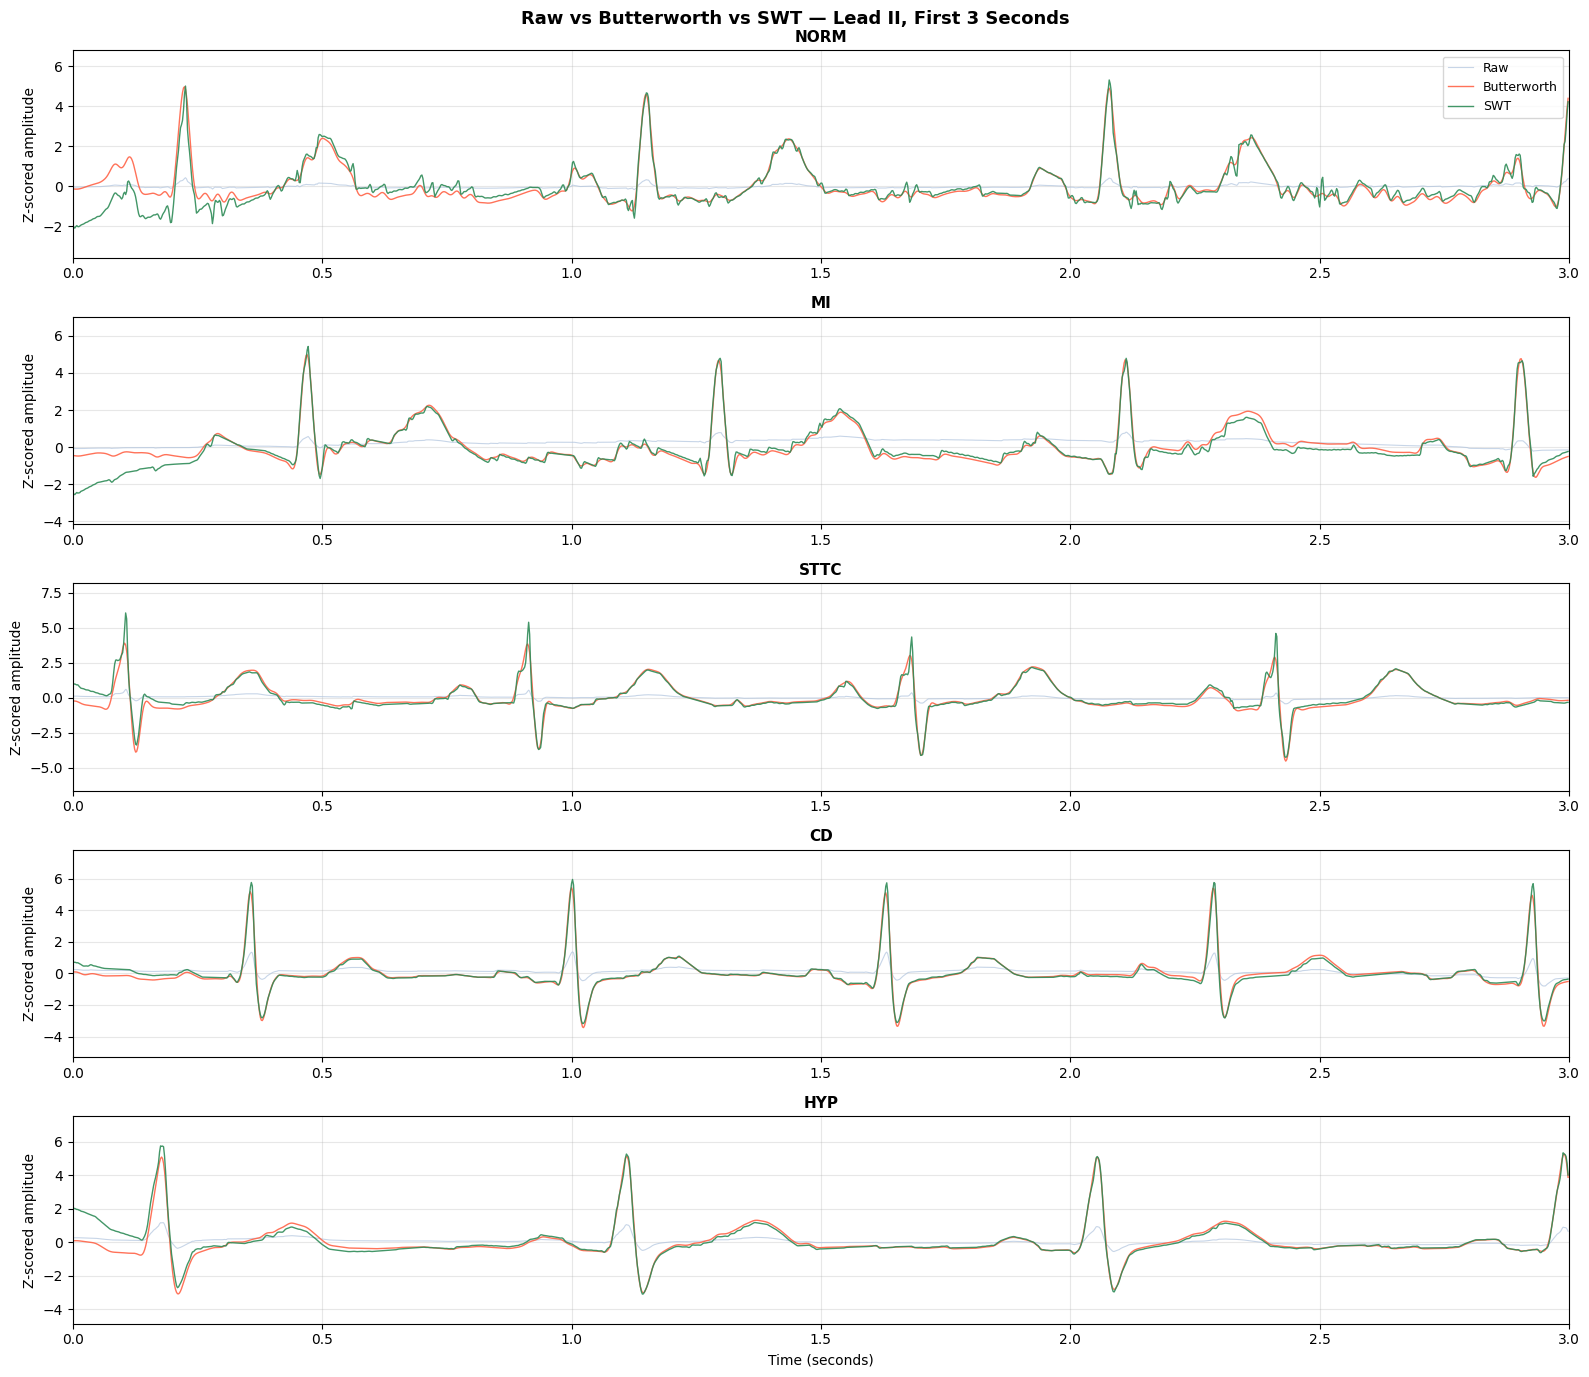

In [9]:
# one sample per class: overlay raw,butterworth,swt
fig,axes=plt.subplots(5,1,figsize=(16,14),sharey=False)
time_axis=np.arange(FS*3)/FS  # first 3 seconds

for i,cls in enumerate(SUPERCLASSES):
    row=df_filtered[df_filtered['superclass'].apply(lambda x: cls in x)].iloc[0]
    raw_3lead=load_record(row)
    raw=raw_3lead[MORPH_LEAD]

    butter_out=zscore(butterworth_filter(raw_3lead[MORPH_LEAD]))
    swt_out=zscore(swt_filter(raw_3lead[MORPH_LEAD]))

    ax=axes[i]
    ax.plot(time_axis,raw[:FS*3],color='lightsteelblue',lw=0.8,alpha=0.7,label='Raw')
    ax.plot(time_axis,butter_out[:FS*3],color='tomato',lw=1.0,alpha=0.9,label='Butterworth')
    ax.plot(time_axis,swt_out[:FS*3],color='seagreen',lw=1.0,alpha=0.9,label='SWT')

    sig_min=min(butter_out[:FS*3].min(),swt_out[:FS*3].min())
    sig_max=max(butter_out[:FS*3].max(),swt_out[:FS*3].max())
    padding=(sig_max-sig_min)*0.2
    ax.set_ylim([sig_min-padding,sig_max+padding])
    ax.set_title(f"{cls}",fontsize=11,fontweight='bold')
    ax.set_ylabel("Z-scored amplitude")
    ax.set_xlim([0,3])
    ax.grid(True, alpha=0.3)
    if i==0:
        ax.legend(loc='upper right',fontsize=9)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("Raw vs Butterworth vs SWT — Lead II, First 3 Seconds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4b.2 P/QRS/T Boundary Visualization — SWT Denoised Lead II

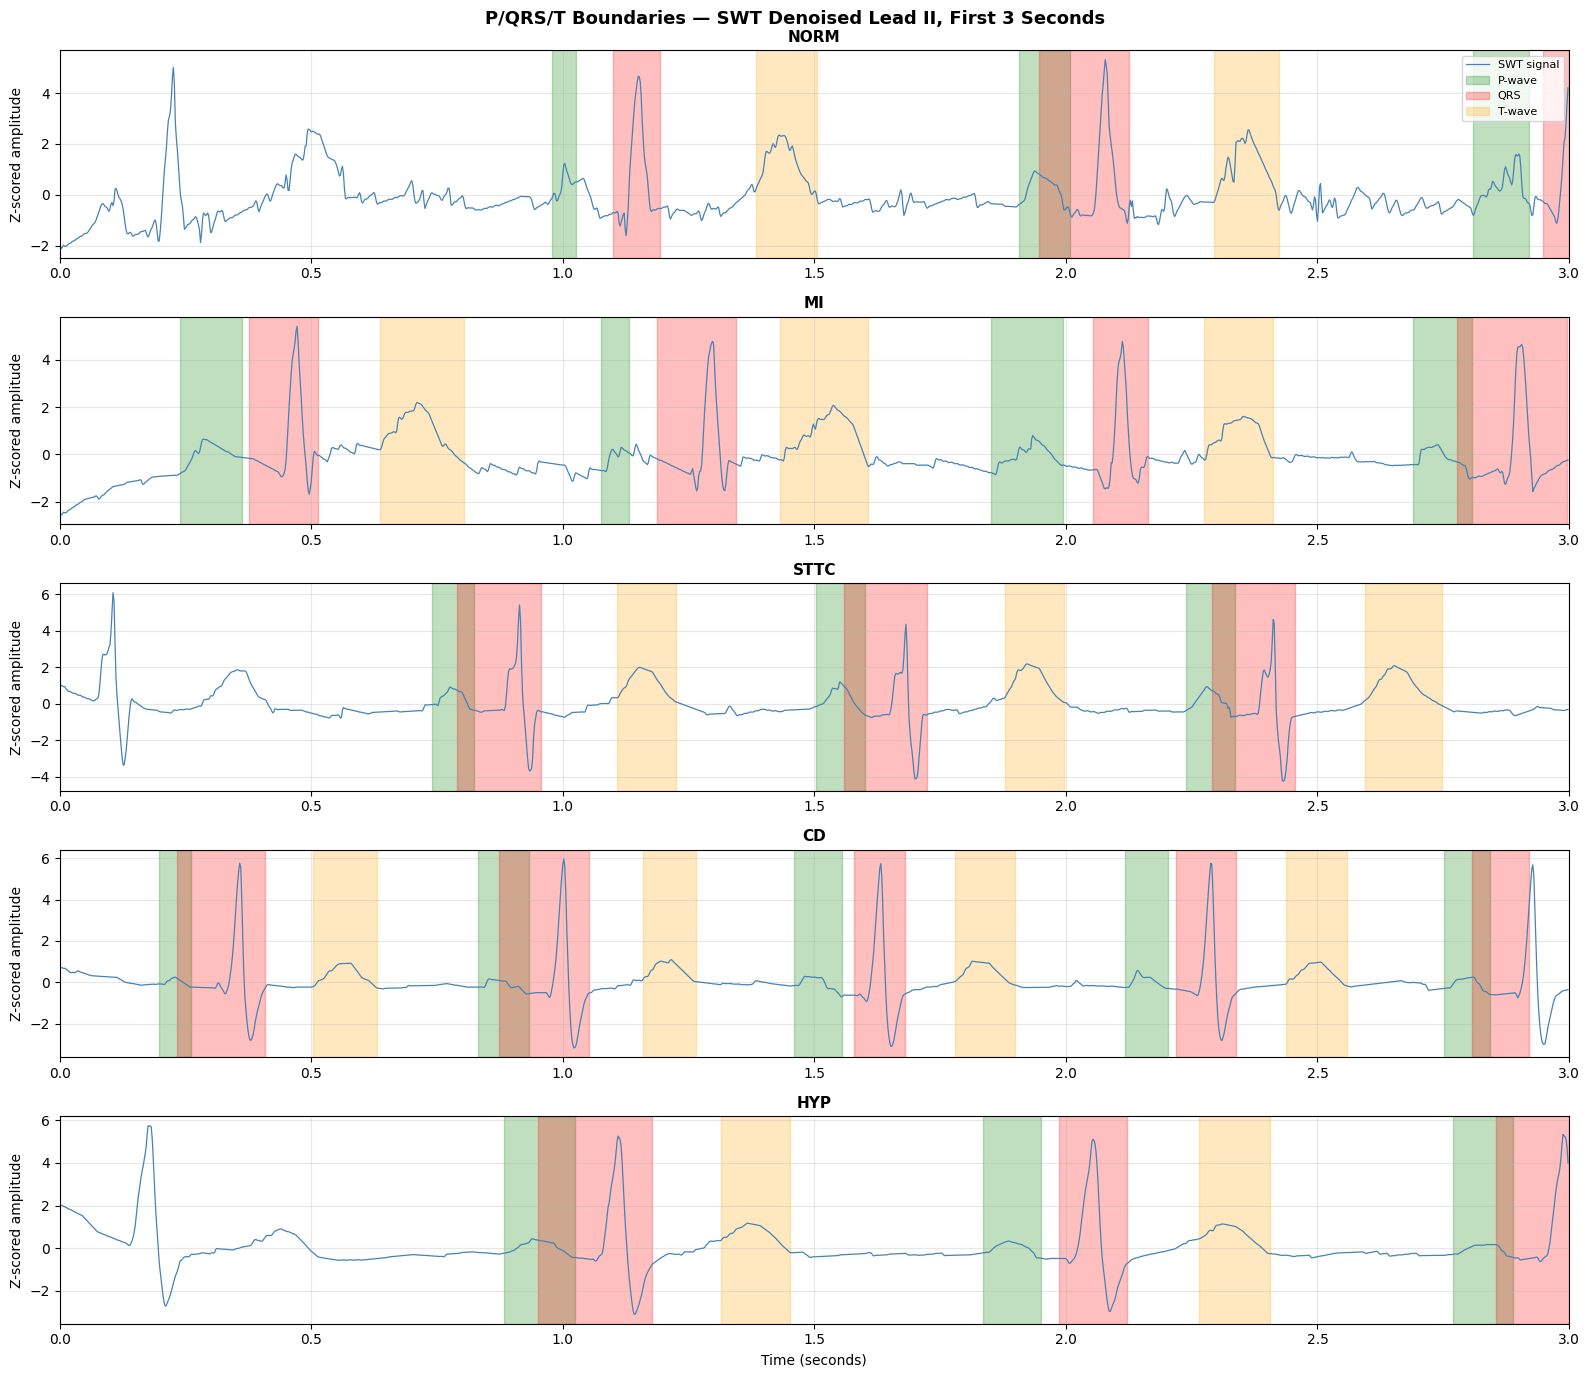

In [10]:
# P/QRS/T boundaries on one SWT-denoised sample per class
fig,axes=plt.subplots(5,1,figsize=(16,14),sharey=False)
time_axis=np.arange(FS*3)/FS

for i,cls in enumerate(SUPERCLASSES):
    row=df_filtered[df_filtered['superclass'].apply(lambda x: cls in x)].iloc[0]
    raw_3lead =load_record(row)
    signal_3lead=np.empty_like(raw_3lead)
    
    for lead_idx in range(N_LEADS):
        signal_3lead[lead_idx]=zscore(swt_filter(raw_3lead[lead_idx]))
        
    signal=signal_3lead[MORPH_LEAD]
    boundaries=extract_boundaries_multilead(signal_3lead)

    ax=axes[i]
    ax.plot(time_axis,signal[:FS*3],color='steelblue',lw=0.9,label='SWT signal')

    if boundaries is not None:
        plot_end=FS*3

        # P-wave (green)
        p_on=boundaries['p_onsets']
        p_off=boundaries['p_offsets']
        first_p=True
        for on,off in zip(p_on,p_off):
            if np.isnan(on) or np.isnan(off) or on>=plot_end:
                continue
            ax.axvspan(on/FS,min(off/FS,3.0),color='green',alpha=0.25,
                       label='P-wave' if first_p else "")
            first_p=False

        # QRS (red)
        q_on=boundaries['qrs_onsets']
        q_off=boundaries['qrs_offsets']
        first_q=True
        for on,off in zip(q_on,q_off):
            if np.isnan(on) or np.isnan(off) or on>=plot_end:
                continue
            ax.axvspan(on/FS,min(off/FS,3.0),color='red',alpha=0.25,
                       label='QRS' if first_q else "")
            first_q=False

        # T-wave (orange)
        t_on=boundaries['t_onsets']
        t_off=boundaries['t_offsets']
        first_t=True
        for on,off in zip(t_on,t_off):
            if np.isnan(on) or np.isnan(off) or on>=plot_end:
                continue
            ax.axvspan(on/FS,min(off/FS,3.0),color='orange',alpha=0.25,
                       label='T-wave' if first_t else "")
            first_t=False

    ax.set_title(f"{cls}",fontsize=11,fontweight='bold')
    ax.set_ylabel("Z-scored amplitude")
    ax.set_xlim([0,3])
    ax.grid(True,alpha=0.3)
    if i==0:
        ax.legend(loc='upper right',fontsize=8)

axes[-1].set_xlabel("Time (seconds)")
plt.suptitle("P/QRS/T Boundaries — SWT Denoised Lead II, First 3 Seconds",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4b.3 LBWA Augmentation — Original vs Augmented (MI Sample)

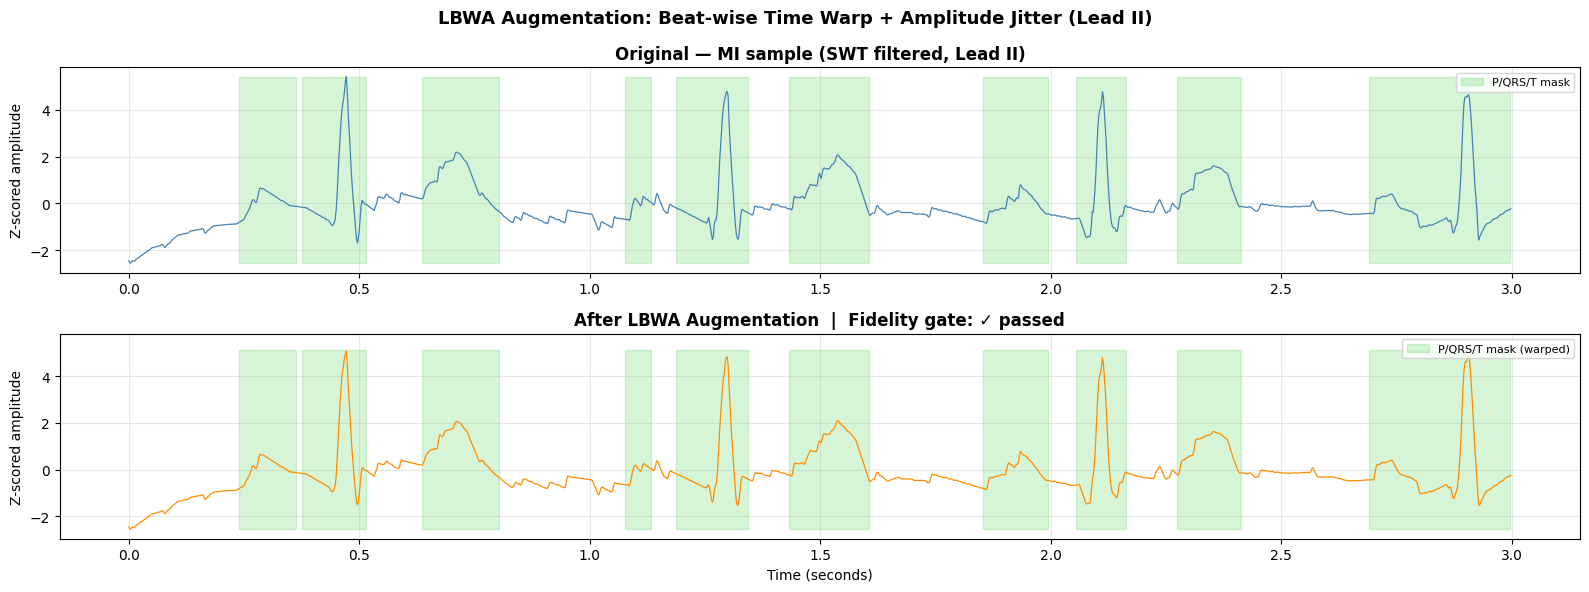

Fidelity gate : ✓ passed (attempts=1)


In [11]:
# Smoke test: one MI sample, showing original vs after augmentation
sample_row=df_filtered[df_filtered['superclass'].apply(lambda x: 'MI' in x)].iloc[0]
raw_3lead=load_record(sample_row)
signal_3lead=np.empty_like(raw_3lead)

for i in range(N_LEADS):
    signal_3lead[i]=zscore(swt_filter(raw_3lead[i]))

# building the mask then augmenting
mask,boundaries=build_mask_for_record(signal_3lead)
aug_3lead,aug_mask,_,gate_ok,gate_attempts=augment_with_fidelity_retry(
    signal_3lead, mask, boundaries=boundaries, max_retries=AUG_MAX_RETRIES
)

time_axis=np.arange(FS*3)/FS
lead_ii_orig=signal_3lead[MORPH_LEAD]
lead_ii_aug=aug_3lead[MORPH_LEAD]

fig,axes=plt.subplots(2,1,figsize=(16,6),sharey=True)

axes[0].plot(time_axis,lead_ii_orig[:FS*3],color='steelblue',lw=0.9)
axes[0].fill_between(time_axis,lead_ii_orig[:FS*3].min(),lead_ii_orig[:FS*3].max(),
                     where=mask[:FS*3].astype(bool),color='limegreen',alpha=0.2,label='P/QRS/T mask')
axes[0].set_title("Original — MI sample (SWT filtered, Lead II)",fontweight='bold')
axes[0].set_ylabel("Z-scored amplitude")
axes[0].legend(loc='upper right',fontsize=8)
axes[0].grid(True,alpha=0.3)

axes[1].plot(time_axis,lead_ii_aug[:FS*3],color='darkorange',lw=0.9)
axes[1].fill_between(time_axis,lead_ii_aug[:FS*3].min(),lead_ii_aug[:FS*3].max(),
                     where=aug_mask[:FS*3].astype(bool),color='limegreen',alpha=0.2, label='P/QRS/T mask (warped)')
axes[1].set_title(f"After LBWA Augmentation  |  Fidelity gate: {'✓ passed' if gate_ok else '✗ failed'}",
                  fontweight='bold')
axes[1].set_ylabel("Z-scored amplitude")
axes[1].set_xlabel("Time (seconds)")
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("LBWA Augmentation: Beat-wise Time Warp + Amplitude Jitter (Lead II)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Fidelity gate : {'✓ passed' if gate_ok else '✗ failed'} (attempts={gate_attempts})")

## 5. Build and Save 5 Condition Datasets (X, y, M)

This is the heaviest part of the pipeline and now uses a cache + parallel strategy.

Workflow in this section:
- Build or reuse per-record cache files for each preprocessing mode (Butterworth, SWT, raw z-score).
- Assemble split tensors (`X`, `y`, `M`) from cache and apply augmentation only where configured.
- Save train/val/test split files with condition metadata for reproducibility.

Practical notes:
- Keep `FORCE_REBUILD_DATASETS = False` to resume safely and skip already-saved splits.
- If preprocessing logic changes, bump `CACHE_VERSION` to rebuild cache consistently.

In [12]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

CACHE_VERSION = 'v1_parallel_cache'
CACHE_ROOT = os.path.join(SAVE_PATH, '_record_cache', CACHE_VERSION)
# DATASET_BUILD_WORKERS = max(1, min(6, (os.cpu_count() or 2) - 1))
DATASET_BUILD_WORKERS = 4
DATASET_POOL_CHUNK = 16
CACHE_PROGRESS_EVERY = 500
os.makedirs(CACHE_ROOT, exist_ok=True)
# Cache layout: <SAVE_PATH>/_record_cache/<version>/<mode>/<bucket>/<ecg_id>.npz


def _mode_name(use_swt=False, use_raw_no_filter=False):
    if use_raw_no_filter:
        return 'raw_zscore'
    return 'swt' if use_swt else 'butter'


def _cache_path_for(mode_name, ecg_id, create_dirs=False):
    ecg_id = int(ecg_id)
    bucket = f"{(ecg_id // 1000) * 1000:05d}"
    cache_dir = os.path.join(CACHE_ROOT, mode_name, bucket)
    if create_dirs:
        os.makedirs(cache_dir, exist_ok=True)
    return os.path.join(cache_dir, f"{ecg_id:05d}.npz")


def _row_to_task(row_idx, row):
    y = np.array([row[c] for c in SUPERCLASSES], dtype=np.float32)
    is_minority = bool(any(row[c] == 1 for c in MINORITY))
    return {
        'ecg_id': int(row_idx),
        'filename_hr': row['filename_hr'],
        'y': y,
        'is_minority': is_minority,
    }


def _compute_cached_record_worker(args):
    task, use_swt, use_raw_no_filter = args
    mode_name = _mode_name(use_swt=use_swt, use_raw_no_filter=use_raw_no_filter)
    cache_path = _cache_path_for(mode_name, task['ecg_id'], create_dirs=True)

    # Fast path when this record-mode pair is already cached.
    if os.path.exists(cache_path):
        return True, task['ecg_id'], 'hit', ''

    tmp_path = cache_path + f".tmp.{os.getpid()}.npz"
    # Atomic write avoids partially-written cache files on interrupts.
    try:
        row = {'filename_hr': task['filename_hr']}
        if use_raw_no_filter:
            x = preprocess_record_raw_zscore(row)
        else:
            x = preprocess_record(row, use_swt=use_swt)

        mask, _ = build_mask_for_record(x)
        np.savez(tmp_path, X=x.astype(np.float32), M=mask.astype(np.float32))
        os.replace(tmp_path, cache_path)
        return True, task['ecg_id'], 'miss', ''
    except Exception as exc:
        try:
            if os.path.exists(tmp_path):
                os.remove(tmp_path)
        except Exception:
            pass
        return False, task['ecg_id'], 'error', repr(exc)


def _iter_worker_args(tasks, use_swt=False, use_raw_no_filter=False):
    for task in tasks:
        yield task, use_swt, use_raw_no_filter


def _ensure_split_cache(tasks, use_swt=False, use_raw_no_filter=False, split_name=''):
    mode_name = _mode_name(use_swt=use_swt, use_raw_no_filter=use_raw_no_filter)
    # Only compute items that do not exist in persistent cache yet.
    missing = [
        t for t in tasks
        if not os.path.exists(_cache_path_for(mode_name, t['ecg_id'], create_dirs=False))
    ]

    total = len(tasks)
    if len(missing) == 0:
        print(f"  Cache ready for {split_name}: 100% hit ({total}/{total})")
        return

    # Cap workers so we do not oversubscribe on smaller splits.
    n_workers = min(DATASET_BUILD_WORKERS, len(missing))
    print(
        f"  Caching {split_name}: mode={mode_name} | "
        f"missing={len(missing)}/{total} | workers={n_workers}"
    )

    built = 0
    failed = 0
    hits = total - len(missing)
    sample_errors = []

    def _update_stats(result):
        nonlocal built, failed
        ok, _, state, err = result
        if ok and state == 'miss':
            built += 1
        elif not ok:
            failed += 1
            if len(sample_errors) < 5:
                sample_errors.append(err)

    def _run_serial(todo):
        for i, result in enumerate(_map_serial(todo), 1):
            _update_stats(result)
            if i % CACHE_PROGRESS_EVERY == 0 or i == len(todo):
                print(f"    cache progress {i}/{len(todo)} | built={built} failed={failed}", end='\r')
        print()

    def _map_serial(todo):
        for args in _iter_worker_args(todo, use_swt=use_swt, use_raw_no_filter=use_raw_no_filter):
            yield _compute_cached_record_worker(args)

    if n_workers <= 1:
        _run_serial(missing)
    else:
        # Use process workers for CPU-heavy preprocessing and delineation.
        try:
            ctx = mp.get_context('fork')
            with ProcessPoolExecutor(max_workers=n_workers, mp_context=ctx) as ex:
                result_iter = ex.map(
                    _compute_cached_record_worker,
                    _iter_worker_args(missing, use_swt=use_swt, use_raw_no_filter=use_raw_no_filter),
                    chunksize=DATASET_POOL_CHUNK,
                )
                for i, result in enumerate(result_iter, 1):
                    _update_stats(result)
                    if i % CACHE_PROGRESS_EVERY == 0 or i == len(missing):
                        print(f"    cache progress {i}/{len(missing)} | built={built} failed={failed}", end='\r')
                print()
        except Exception as exc:
            print(f"    multiprocessing cache build failed ({exc}); using serial fallback.")
            # Fallback keeps dataset creation robust across runtime environments.
            _run_serial(missing)

    print(f"  Cache summary {split_name}: hits={hits} built={built} failed={failed}")
    if sample_errors:
        print("  Sample cache errors:")
        for e in sample_errors:
            print(f"    - {e}")


def _load_cached_record(task, use_swt=False, use_raw_no_filter=False):
    mode_name = _mode_name(use_swt=use_swt, use_raw_no_filter=use_raw_no_filter)
    cache_path = _cache_path_for(mode_name, task['ecg_id'], create_dirs=False)
    with np.load(cache_path, allow_pickle=False) as data:
        x = data['X'].astype(np.float32, copy=False)
        m = data['M'].astype(np.float32, copy=False)
    return x, m


def build_dataset(df_split, use_swt=False, use_aug=False, use_raw_no_filter=False, split_name=''):
    tasks = [_row_to_task(idx, row) for idx, row in df_split.iterrows()]
    total = len(tasks)
    failed = 0
    aug_kept = 0
    aug_rejected = 0

    print(
        f"  Building {split_name}: SWT={use_swt}, AUG={use_aug}, "
        f"RAW_NO_FILTER={use_raw_no_filter} | {total} records"
    )
    # Stage 1: warm/reuse cache for this split and preprocessing mode.
    _ensure_split_cache(
        tasks,
        use_swt=use_swt,
        use_raw_no_filter=use_raw_no_filter,
        split_name=split_name,
    )

    X_list, y_list, m_list = [], [], []
    # Stage 2: assemble tensors from cache; apply optional augmentation here.
    for idx, task in enumerate(tasks):
        if idx % 500 == 0:
            print(f"{idx}/{total}", end='\r')

        try:
            x, mask = _load_cached_record(task, use_swt=use_swt, use_raw_no_filter=use_raw_no_filter)
            y = task['y']

            X_list.append(x)
            y_list.append(y)
            m_list.append(mask)

            if use_aug and (not use_raw_no_filter) and task['is_minority']:
                # Augment minority samples only, keeping majority class untouched.
                aug_x, aug_m, _, gate_ok, _ = augment_with_fidelity_retry(
                    x, mask, boundaries=None, max_retries=AUG_MAX_RETRIES
                )
                if gate_ok:
                    X_list.append(aug_x.astype(np.float32))
                    y_list.append(y.copy())
                    m_list.append(aug_m.astype(np.float32))
                    aug_kept += 1
                else:
                    aug_rejected += 1
        except Exception:
            failed += 1

    if len(X_list) == 0:
        raise RuntimeError(f"No valid records produced for {split_name}. failed={failed}")

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.stack(y_list, axis=0).astype(np.float32)
    M = np.stack(m_list, axis=0).astype(np.float32)

    print(f"    Done: X={X.shape}, y={y.shape}, M={M.shape}, failed={failed}")
    if use_aug:
        print(f"    Aug kept={aug_kept}, rejected={aug_rejected}")
    print(f"    Mean mask coverage={M.mean() * 100:.2f}%")
    return X, y, M


def _save_split_tensor(
    df_split,
    split_path,
    split_name,
    use_swt=False,
    use_aug=False,
    use_raw_no_filter=False,
    force_rebuild=False,
    meta=None,
    condition_name='',
):
    # Reuse saved split artifacts to make interrupted runs resumable.
    if (not force_rebuild) and os.path.exists(split_path):
        print(f"Reuse existing split: {condition_name}/{split_name}")
        return

    X, y, M = build_dataset(
        df_split,
        use_swt=use_swt,
        use_aug=use_aug,
        use_raw_no_filter=use_raw_no_filter,
        split_name=f"{condition_name}/{split_name}",
    )
    torch.save(
        {'X': torch.from_numpy(X), 'y': torch.from_numpy(y), 'M': torch.from_numpy(M), 'meta': meta},
        split_path,
    )
    print(f"Saved split: {condition_name}/{split_name} -> {split_path}")


def save_condition(condition_spec, force_rebuild=False):
    name = condition_spec['name']
    use_swt = condition_spec['use_swt']
    use_aug = condition_spec['use_aug']
    use_raw_no_filter = condition_spec['use_raw_no_filter']

    save_dir = os.path.join(SAVE_PATH, name)
    train_path = os.path.join(save_dir, 'train.pt')
    val_path = os.path.join(save_dir, 'val.pt')
    test_path = os.path.join(save_dir, 'test.pt')

    if (not force_rebuild and os.path.exists(train_path)
            and os.path.exists(val_path) and os.path.exists(test_path)):
        print(f"Skip existing condition: {name}")
        return

    os.makedirs(save_dir, exist_ok=True)

    meta = {
        'condition': name,
        'superclasses': SUPERCLASSES,
        'lead_names': LEAD_NAMES,
        'signal_len': SIGNAL_LEN,
        'morph_lead': MORPH_LEAD,
        'use_swt': use_swt,
        'use_aug': use_aug,
        'use_raw_no_filter': use_raw_no_filter,
        'mask_definition': '1 where P/QRS/T, else 0',
        'cache_version': CACHE_VERSION,
    }

    # Save splits independently so partial progress is preserved on interruption.
    _save_split_tensor(
        train_df,
        train_path,
        'train',
        use_swt=use_swt,
        use_aug=use_aug,
        use_raw_no_filter=use_raw_no_filter,
        force_rebuild=force_rebuild,
        meta=meta,
        condition_name=name,
    )
    _save_split_tensor(
        val_df,
        val_path,
        'val',
        use_swt=use_swt,
        use_aug=False,
        use_raw_no_filter=use_raw_no_filter,
        force_rebuild=force_rebuild,
        meta=meta,
        condition_name=name,
    )
    _save_split_tensor(
        test_df,
        test_path,
        'test',
        use_swt=use_swt,
        use_aug=False,
        use_raw_no_filter=use_raw_no_filter,
        force_rebuild=force_rebuild,
        meta=meta,
        condition_name=name,
    )

    print(f"Saved condition: {name} -> {save_dir}")


FORCE_REBUILD_DATASETS = False
for spec in CONDITION_SPECS:
    save_condition(spec, force_rebuild=FORCE_REBUILD_DATASETS)


# quick shape verification

for spec in CONDITION_SPECS:
    name = spec['name']
    data = torch.load(os.path.join(SAVE_PATH, name, 'train.pt'), map_location='cpu')
    print(f"{name:<22} X={tuple(data['X'].shape)} y={tuple(data['y'].shape)} M={tuple(data['M'].shape)}")

print('All condition datasets ready.')

Skip existing condition: A_butter_noaug
Skip existing condition: B_butter_lbwa
Skip existing condition: C_swt_noaug
Skip existing condition: D_swt_lbwa
Skip existing condition: E_raw_no_preprocess
A_butter_noaug         X=(17100, 3, 5000) y=(17100, 5) M=(17100, 5000)
B_butter_lbwa          X=(26919, 3, 5000) y=(26919, 5) M=(26919, 5000)
C_swt_noaug            X=(17100, 3, 5000) y=(17100, 5) M=(17100, 5000)
D_swt_lbwa             X=(26918, 3, 5000) y=(26918, 5) M=(26918, 5000)
E_raw_no_preprocess    X=(17100, 3, 5000) y=(17100, 5) M=(17100, 5000)
All condition datasets ready.


## 6a. Shared Model and Evaluation Core

All five conditions below use the same model/training/evaluation setup to keep the ablation fair.

What this section covers:
- Baseline ResNet1D architecture definition.
- Baseline Grad-CAM logic used for interpretability/MAS.
- Per-condition training with early stopping and LR scheduling.
- Common metrics: Macro-AUC, Macro-F1, per-class AUC, and MAS.

In [13]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_CLASSES = len(SUPERCLASSES)

# Training hyperparameters (kept close to baseline)
TRAIN_BATCH_SIZE = 64
TRAIN_LR = 1e-3
TRAIN_WEIGHT_DECAY = 1e-4
TRAIN_EPOCHS = 35
TRAIN_PATIENCE = 8
TRAIN_LR_PATIENCE = 4
TRAIN_LR_FACTOR = 0.1
PRED_THRESHOLD = 0.5
MAX_MAS_SAMPLES = 256

print(f"Device: {DEVICE}")
print(f"Train epochs: {TRAIN_EPOCHS} | batch: {TRAIN_BATCH_SIZE}")

Device: cuda
Train epochs: 35 | batch: 64


In [14]:
# -----------------------------------------------------------------------------
# 1D-ResNet architecture (extracted from baseline notebook)
# -----------------------------------------------------------------------------
import torch.nn as nn
import torch.nn.functional as F

class ResBlock1D(nn.Module):
    """Basic 1D residual block with optional stride downsampling."""

    def __init__(self, in_ch, out_ch, stride=1, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(0.2)

        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(out)
        return F.relu(out + self.skip(x))


class ResNet1D(nn.Module):
    """Baseline-compatible 1D-ResNet for multi-label ECG classification."""

    def __init__(self, n_leads=N_LEADS, n_classes=N_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = self._make_stage(32, 32, 2, stride=1, kernel_size=15)
        self.stage2 = self._make_stage(32, 64, 2, stride=2, kernel_size=15)
        self.stage3 = self._make_stage(64, 128, 2, stride=2, kernel_size=7)
        self.stage4 = self._make_stage(128, 256, 2, stride=2, kernel_size=7)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(256, n_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    @staticmethod
    def _make_stage(in_ch, out_ch, n_blocks, stride, kernel_size):
        layers = [ResBlock1D(in_ch, out_ch, stride, kernel_size)]
        for _ in range(1, n_blocks):
            layers.append(ResBlock1D(out_ch, out_ch, 1, kernel_size))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x)

    def get_gradcam_target_layer(self):
        """Last conv before GAP (baseline Grad-CAM target)."""
        return self.stage4[-1].conv2


dummy_model = ResNet1D().to(DEVICE)
with torch.no_grad():
    dummy_out = dummy_model(torch.zeros(2, N_LEADS, SIGNAL_LEN, device=DEVICE))
print(f"ResNet1D forward check: output shape={tuple(dummy_out.shape)}")
print(f"Grad-CAM target layer: {dummy_model.get_gradcam_target_layer()}")

ResNet1D forward check: output shape=(2, 5)
Grad-CAM target layer: Conv1d(256, 256, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)


In [15]:
# -----------------------------------------------------------------------------
# Grad-CAM logic (extracted from baseline notebook)
# -----------------------------------------------------------------------------
import torch.nn.functional as F

class GradCAM1D:
    """Gradient-weighted Class Activation Mapping for 1D-ResNet."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.layer_activations = None
        self.layer_gradients = None
        self.fwd_hook = target_layer.register_forward_hook(self.save_activations)
        self.bwd_hook = target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, *_args):
        out = _args[2]
        self.layer_activations = out.detach()

    def save_gradients(self, *_args):
        grad_out = _args[2]
        self.layer_gradients = grad_out[0].detach()

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

    def compute(self, input_tensor, class_idx, output_length=SIGNAL_LEN):
        self.model.eval()
        inp = input_tensor.clone().requires_grad_(True)
        logits = self.model(inp)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.layer_gradients.mean(dim=-1).squeeze()
        act = self.layer_activations.squeeze()
        cam = F.relu((weights[:, None] * act).sum(dim=0))

        cam_np = cam.detach().cpu().numpy()
        cam_up = np.interp(
            np.linspace(0, len(cam_np) - 1, output_length),
            np.arange(len(cam_np)),
            cam_np,
        )
        if cam_up.max() > 1e-10:
            cam_up = cam_up / cam_up.max()
        return cam_up.astype(np.float32)


if 'compute_mas_from_gradcam' not in globals():
    def compute_mas_from_gradcam(gradcam_1d, mask_1d, output_len=SIGNAL_LEN):
        heat = np.asarray(gradcam_1d, dtype=np.float32).reshape(-1)
        mask = np.asarray(mask_1d, dtype=np.float32).reshape(-1)

        if len(mask) != output_len:
            raise ValueError(f"mask length must be {output_len}, got {len(mask)}")

        if len(heat) != output_len:
            x_old = np.linspace(0.0, 1.0, len(heat))
            x_new = np.linspace(0.0, 1.0, output_len)
            heat = np.interp(x_new, x_old, heat).astype(np.float32)

        heat = np.maximum(heat, 0.0)
        denom = float(heat.sum())
        if denom <= 1e-10:
            return 0.0
        return float((heat * mask).sum() / denom)


print("Grad-CAM utilities ready.")

Grad-CAM utilities ready.


In [16]:
import copy
import time

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        _ = kwargs
        return iterable


class ECGTensorDataset(Dataset):
    """Simple tensor-backed dataset containing X, y, and M."""

    def __init__(self, X, y, M):
        self.X = X.float()
        self.y = y.float()
        self.M = M.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.M[idx]


def load_condition_split(condition_name, split_name):
    path = os.path.join(SAVE_PATH, condition_name, f"{split_name}.pt")
    data = torch.load(path, map_location='cpu')
    X = data['X'].float()
    y = data['y'].float()
    M = data['M'].float()
    return X, y, M


def compute_pos_weight_from_y(y_tensor):
    n = y_tensor.shape[0]
    n_pos = y_tensor.sum(dim=0)
    n_neg = n - n_pos
    return (n_neg / torch.clamp(n_pos, min=1.0)).float()


def macro_auc_safe(y_true, y_prob):
    try:
        return float(roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr'))
    except ValueError:
        return float('nan')


def per_class_auc_safe(y_true, y_prob, class_names=SUPERCLASSES):
    out = {}
    for i, cls in enumerate(class_names):
        try:
            out[f"auc_{cls}"] = float(roc_auc_score(y_true[:, i], y_prob[:, i]))
        except ValueError:
            out[f"auc_{cls}"] = float('nan')
    return out


def run_epoch(loader, model, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    # One shared path for train/val keeps metric computation consistent.

    total_loss = 0.0
    all_probs, all_labels = [], []
    total_samples = 0

    # Enable grads only in training mode.
    with torch.set_grad_enabled(train_mode):
        for xb, yb, _ in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = xb.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # Keep full-epoch predictions for AUC/F1 calculation.
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            labels = yb.detach().cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels)

    avg_loss = total_loss / max(total_samples, 1)

    if len(all_probs) == 0:
        return avg_loss, float('nan'), np.empty((0, N_CLASSES)), np.empty((0, N_CLASSES))

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    macro_auc = macro_auc_safe(y_true, y_prob)
    return avg_loss, macro_auc, y_true, y_prob


def evaluate_predictions(y_true, y_prob, threshold=PRED_THRESHOLD):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'test_macro_auc': macro_auc_safe(y_true, y_prob),
        'test_macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }
    metrics.update(per_class_auc_safe(y_true, y_prob, SUPERCLASSES))
    return metrics


def compute_condition_mas(model, dataset, max_samples=MAX_MAS_SAMPLES):
    """Compute MAS on a subset of test samples using top-probability class Grad-CAM."""
    if len(dataset) == 0:
        return float('nan'), float('nan')

    n = min(max_samples, len(dataset))
    rng = np.random.default_rng(SEED)
    idxs = rng.choice(len(dataset), size=n, replace=False) if n < len(dataset) else np.arange(len(dataset))

    gcam = GradCAM1D(model, model.get_gradcam_target_layer())
    mas_values = []

    for idx in idxs:
        x, _, m = dataset[int(idx)]
        x = x.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).squeeze(0).cpu().numpy()
        class_idx = int(np.argmax(prob))

        heat = gcam.compute(x, class_idx, output_length=SIGNAL_LEN)
        mas = compute_mas_from_gradcam(heat, m.cpu().numpy(), output_len=SIGNAL_LEN)
        mas_values.append(mas)

    gcam.remove_hooks()

    mas_values = np.asarray(mas_values, dtype=np.float32)
    return float(np.mean(mas_values)), float(np.std(mas_values))


def train_one_condition(condition_name, epochs=TRAIN_EPOCHS, patience=TRAIN_PATIENCE):
    print(f"\n{'=' * 80}")
    print(f"Training condition: {condition_name}")
    print(f"{'=' * 80}")

    X_train, y_train, M_train = load_condition_split(condition_name, 'train')
    X_val, y_val, M_val = load_condition_split(condition_name, 'val')
    X_test, y_test, M_test = load_condition_split(condition_name, 'test')

    train_ds = ECGTensorDataset(X_train, y_train, M_train)
    val_ds = ECGTensorDataset(X_val, y_val, M_val)
    test_ds = ECGTensorDataset(X_test, y_test, M_test)

    train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=TRAIN_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    pos_weight = compute_pos_weight_from_y(y_train).to(DEVICE)
    model = ResNet1D().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_LR, weight_decay=TRAIN_WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=TRAIN_LR_FACTOR, patience=TRAIN_LR_PATIENCE
    )

    best_val_auc = -np.inf
    best_epoch = 0
    best_state = None
    no_improve = 0

    for epoch in tqdm(range(1, epochs + 1), desc=f"{condition_name} epochs", unit='epoch'):
        t0 = time.time()
        train_loss, train_auc, _, _ = run_epoch(train_loader, model, criterion, optimizer=optimizer)
        val_loss, val_auc, _, _ = run_epoch(val_loader, model, criterion, optimizer=None)

        sched_metric = val_auc if np.isfinite(val_auc) else -1.0
        scheduler.step(sched_metric)

        lr_now = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_auc={train_auc:.4f} | "
            f"val_loss={val_loss:.4f} val_auc={val_auc:.4f} | "
            f"lr={lr_now:.2e} | sec={time.time() - t0:.1f}"
        )

        # Track best checkpoint by validation Macro-AUC.
        if np.isfinite(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # Restore best validation checkpoint before test-time evaluation.
    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, _, y_true, y_prob = run_epoch(test_loader, model, criterion, optimizer=None)
    test_metrics = evaluate_predictions(y_true, y_prob, threshold=PRED_THRESHOLD)
    mas_mean, mas_std = compute_condition_mas(model, test_ds, max_samples=MAX_MAS_SAMPLES)

    ckpt_dir = os.path.join(SAVE_PATH, 'training_checkpoints', condition_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, 'best_model.pt')
    torch.save({
        'condition': condition_name,
        'model_state_dict': model.state_dict(),
        'best_val_auc': best_val_auc,
        'best_epoch': best_epoch,
        'superclasses': SUPERCLASSES,
        'signal_len': SIGNAL_LEN,
        'n_leads': N_LEADS,
    }, ckpt_path)

    result = {
        'condition': condition_name,
        'best_epoch': int(best_epoch),
        'best_val_auc': float(best_val_auc),
        'test_loss': float(test_loss),
        'test_mean_mas': mas_mean,
        'test_std_mas': mas_std,
        'checkpoint': ckpt_path,
    }
    result.update(test_metrics)
    return result

In [17]:
CONDITIONS_TO_TRAIN = [
    'A_butter_noaug',
    'B_butter_lbwa',
    'C_swt_noaug',
    'D_swt_lbwa',
    RAW_CONDITION_NAME,
]

CONDITION_LABELS = {
    'A_butter_noaug': ('Butterworth', 'None'),
    'B_butter_lbwa': ('Butterworth', 'LBWA'),
    'C_swt_noaug': ('Selective SWT', 'None'),
    'D_swt_lbwa': ('Selective SWT', 'LBWA'),
    RAW_CONDITION_NAME: ('Raw + Z-score (no filter)', 'None'),
}

all_results = []
for cond in CONDITIONS_TO_TRAIN:
    res = train_one_condition(cond, epochs=TRAIN_EPOCHS, patience=TRAIN_PATIENCE)
    denoise, aug = CONDITION_LABELS.get(cond, ('Unknown', 'Unknown'))
    res['denoising'] = denoise
    res['augmentation'] = aug
    all_results.append(res)

results_df = pd.DataFrame(all_results)
results_df = results_df[[
    'condition', 'denoising', 'augmentation',
    'best_epoch', 'best_val_auc',
    'test_macro_auc', 'test_macro_f1', 'test_mean_mas', 'test_std_mas',
    'auc_NORM', 'auc_MI', 'auc_STTC', 'auc_CD', 'auc_HYP',
    'checkpoint',
]]

results_path = os.path.join(SAVE_PATH, 'condition_comparison_results.csv')
results_df.to_csv(results_path, index=False)

print("\n=== Condition Comparison (sorted by test_macro_auc) ===")
display(results_df.sort_values('test_macro_auc', ascending=False).reset_index(drop=True))
print(f"\nResults saved to: {results_path}")


Training condition: A_butter_noaug


A_butter_noaug epochs:   0%|          | 0/35 [00:00<?, ?epoch/s]

Epoch 01/35 | train_loss=0.7517 train_auc=0.8481 | val_loss=0.7225 val_auc=0.8696 | lr=1.00e-03 | sec=30.6
Epoch 02/35 | train_loss=0.6342 train_auc=0.8836 | val_loss=0.6422 val_auc=0.8858 | lr=1.00e-03 | sec=30.4
Epoch 03/35 | train_loss=0.6059 train_auc=0.8939 | val_loss=0.6303 val_auc=0.8889 | lr=1.00e-03 | sec=30.4
Epoch 04/35 | train_loss=0.6000 train_auc=0.8962 | val_loss=0.6758 val_auc=0.8848 | lr=1.00e-03 | sec=30.4
Epoch 05/35 | train_loss=0.5822 train_auc=0.9028 | val_loss=0.6522 val_auc=0.8881 | lr=1.00e-03 | sec=30.4
Epoch 06/35 | train_loss=0.5748 train_auc=0.9050 | val_loss=0.6334 val_auc=0.8929 | lr=1.00e-03 | sec=30.4
Epoch 07/35 | train_loss=0.5664 train_auc=0.9080 | val_loss=0.6379 val_auc=0.8902 | lr=1.00e-03 | sec=30.4
Epoch 08/35 | train_loss=0.5590 train_auc=0.9106 | val_loss=0.6309 val_auc=0.8958 | lr=1.00e-03 | sec=30.4
Epoch 09/35 | train_loss=0.5520 train_auc=0.9128 | val_loss=0.6522 val_auc=0.8908 | lr=1.00e-03 | sec=30.4
Epoch 10/35 | train_loss=0.5506 train

B_butter_lbwa epochs:   0%|          | 0/35 [00:00<?, ?epoch/s]

Epoch 01/35 | train_loss=0.7093 train_auc=0.8488 | val_loss=0.6737 val_auc=0.8799 | lr=1.00e-03 | sec=47.0
Epoch 02/35 | train_loss=0.6221 train_auc=0.8802 | val_loss=0.5935 val_auc=0.8915 | lr=1.00e-03 | sec=47.1
Epoch 03/35 | train_loss=0.5962 train_auc=0.8902 | val_loss=0.6227 val_auc=0.8929 | lr=1.00e-03 | sec=47.0
Epoch 04/35 | train_loss=0.5820 train_auc=0.8961 | val_loss=0.5907 val_auc=0.8924 | lr=1.00e-03 | sec=47.0
Epoch 05/35 | train_loss=0.5741 train_auc=0.8991 | val_loss=0.6537 val_auc=0.8857 | lr=1.00e-03 | sec=47.0
Epoch 06/35 | train_loss=0.5593 train_auc=0.9046 | val_loss=0.5875 val_auc=0.8959 | lr=1.00e-03 | sec=47.0
Epoch 07/35 | train_loss=0.5508 train_auc=0.9077 | val_loss=0.6024 val_auc=0.8928 | lr=1.00e-03 | sec=47.0
Epoch 08/35 | train_loss=0.5378 train_auc=0.9123 | val_loss=0.5596 val_auc=0.8961 | lr=1.00e-03 | sec=47.0
Epoch 09/35 | train_loss=0.5283 train_auc=0.9157 | val_loss=0.5836 val_auc=0.8966 | lr=1.00e-03 | sec=47.0
Epoch 10/35 | train_loss=0.5175 train

...

Epoch 01/35 | train_loss=0.7237 train_auc=0.8431 | val_loss=0.8791 val_auc=0.8800 | lr=1.00e-03 | sec=46.9
Epoch 02/35 | train_loss=0.6219 train_auc=0.8800 | val_loss=0.7174 val_auc=0.8897 | lr=1.00e-03 | sec=46.9
Epoch 03/35 | train_loss=0.5965 train_auc=0.8903 | val_loss=0.6396 val_auc=0.8872 | lr=1.00e-03 | sec=46.9
Epoch 04/35 | train_loss=0.5871 train_auc=0.8940 | val_loss=0.6373 val_auc=0.8954 | lr=1.00e-03 | sec=46.9
Epoch 05/35 | train_loss=0.5673 train_auc=0.9016 | val_loss=0.6004 val_auc=0.8958 | lr=1.00e-03 | sec=46.9
Epoch 06/35 | train_loss=0.5561 train_auc=0.9057 | val_loss=0.6525 val_auc=0.8894 | lr=1.00e-03 | sec=46.9
Epoch 07/35 | train_loss=0.5479 train_auc=0.9089 | val_loss=0.6465 val_auc=0.8854 | lr=1.00e-03 | sec=46.9
Epoch 08/35 | train_loss=0.5333 train_auc=0.9138 | val_loss=0.6127 val_auc=0.8827 | lr=1.00e-03 | sec=46.9
Epoch 09/35 | train_loss=0.5261 train_auc=0.9166 | val_loss=0.6487 val_auc=0.8923 | lr=1.00e-03 | sec=46.9
Epoch 10/35 | train_loss=0.5128 train

E_raw_no_preprocess epochs:   0%|          | 0/35 [00:00<?, ?epoch/s]

Epoch 01/35 | train_loss=0.7980 train_auc=0.8296 | val_loss=1.0871 val_auc=0.8598 | lr=1.00e-03 | sec=30.1
Epoch 02/35 | train_loss=0.6628 train_auc=0.8731 | val_loss=1.1809 val_auc=0.8586 | lr=1.00e-03 | sec=30.1
Epoch 03/35 | train_loss=0.6270 train_auc=0.8870 | val_loss=0.8872 val_auc=0.8720 | lr=1.00e-03 | sec=30.1
Epoch 04/35 | train_loss=0.6143 train_auc=0.8915 | val_loss=0.7655 val_auc=0.8783 | lr=1.00e-03 | sec=30.1
Epoch 05/35 | train_loss=0.5985 train_auc=0.8973 | val_loss=0.8684 val_auc=0.8822 | lr=1.00e-03 | sec=30.1
Epoch 06/35 | train_loss=0.5895 train_auc=0.9002 | val_loss=0.8366 val_auc=0.8833 | lr=1.00e-03 | sec=30.1
Epoch 07/35 | train_loss=0.5748 train_auc=0.9055 | val_loss=0.7959 val_auc=0.8840 | lr=1.00e-03 | sec=30.1
Epoch 08/35 | train_loss=0.5714 train_auc=0.9068 | val_loss=0.7004 val_auc=0.8895 | lr=1.00e-03 | sec=30.1
Epoch 09/35 | train_loss=0.5648 train_auc=0.9090 | val_loss=0.6838 val_auc=0.8936 | lr=1.00e-03 | sec=30.1
Epoch 10/35 | train_loss=0.5576 train

,condition,denoising,augmentation,best_epoch,best_val_auc,test_macro_auc,test_macro_f1,test_mean_mas,test_std_mas,auc_NORM,auc_MI,auc_STTC,auc_CD,auc_HYP,checkpoint
0,E_raw_no_preprocess,Raw + Z-score (no filter),None,17,0.901344,0.898690,0.694938,0.665766,0.181222,0.930496,0.909462,0.916173,0.919032,0.818287,/kaggle/working/training_checkpoints/E_raw_no_...
1,C_swt_noaug,Selective SWT,None,19,0.900562,0.898417,0.683951,0.620108,0.155805,0.930509,0.912414,0.913409,0.926926,0.808827,/kaggle/working/training_checkpoints/C_swt_noa...
2,A_butter_noaug,Butterworth,None,19,0.902621,0.897531,0.695210,0.478147,0.164224,0.929425,0.905603,0.914859,0.923662,0.814107,/kaggle/working/training_checkpoints/A_butter_...
3,B_butter_lbwa,Butterworth,LBWA,13,0.902788,0.894636,0.672224,0.455921,0.191565,0.931301,0.895912,0.911328,0.920509,0.814129,/kaggle/working/training_checkpoints/B_butter_...
4,D_swt_lbwa,Selective SWT,LBWA,5,0.895822,0.893096,0.658187,0.535126,0.156960,0.923581,0.901351,0.913643,0.915220,0.811688,/kaggle/working/training_checkpoints/D_swt_lbw...



Results saved to: /kaggle/working/condition_comparison_results.csv


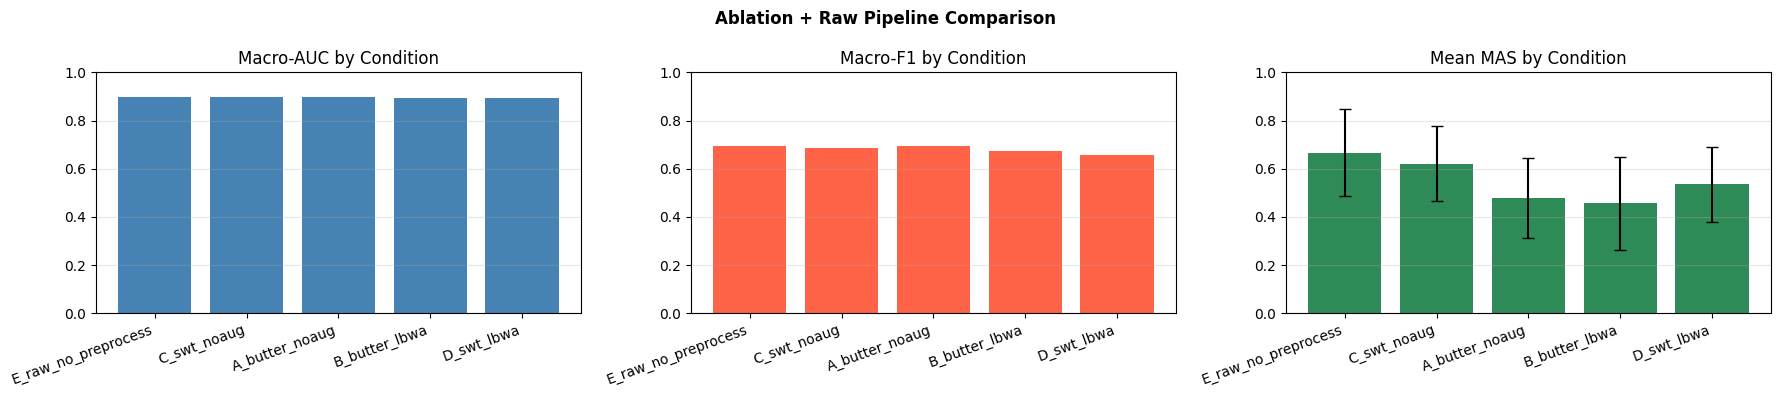

Top condition by metric:
  Macro-AUC : E_raw_no_preprocess
  Macro-F1  : A_butter_noaug
  Mean MAS  : E_raw_no_preprocess

MI and HYP focus (higher is better):


,condition,auc_MI,auc_HYP,test_mean_mas
0,E_raw_no_preprocess,0.909462,0.818287,0.665766
1,C_swt_noaug,0.912414,0.808827,0.620108
2,A_butter_noaug,0.905603,0.814107,0.478147
3,B_butter_lbwa,0.895912,0.814129,0.455921
4,D_swt_lbwa,0.901351,0.811688,0.535126


In [18]:
plot_df = results_df.sort_values('test_macro_auc', ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))
labels = plot_df['condition'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(x, plot_df['test_macro_auc'], color='steelblue')
axes[0].set_title('Macro-AUC by Condition')
axes[0].set_ylim([0, 1.0])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha='right')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(x, plot_df['test_macro_f1'], color='tomato')
axes[1].set_title('Macro-F1 by Condition')
axes[1].set_ylim([0, 1.0])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha='right')
axes[1].grid(True, axis='y', alpha=0.3)

axes[2].bar(x, plot_df['test_mean_mas'], yerr=plot_df['test_std_mas'], capsize=4, color='seagreen')
axes[2].set_title('Mean MAS by Condition')
axes[2].set_ylim([0, 1.0])
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=20, ha='right')
axes[2].grid(True, axis='y', alpha=0.3)

plt.suptitle('Ablation + Raw Pipeline Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

print("Top condition by metric:")
print(f"  Macro-AUC : {plot_df.loc[plot_df['test_macro_auc'].idxmax(), 'condition']}")
print(f"  Macro-F1  : {plot_df.loc[plot_df['test_macro_f1'].idxmax(), 'condition']}")
print(f"  Mean MAS  : {plot_df.loc[plot_df['test_mean_mas'].idxmax(), 'condition']}")

print("\nMI and HYP focus (higher is better):")
display(plot_df[['condition', 'auc_MI', 'auc_HYP', 'test_mean_mas']])

## 6b. Grad-CAM Heatmap Visualisation Per Condition
For each condition we load the saved best checkpoint, attach GradCAM,
and produce a 5-class heatmap figure showing where the model focuses
on the Lead II signal vs the P/QRS/T morphological mask.


Grad-CAM — A_butter_noaug
Selected test sample indices per class:
NORM  : test index 0
MI    : test index 5
STTC  : test index 19
CD    : test index 6
HYP   : test index 24


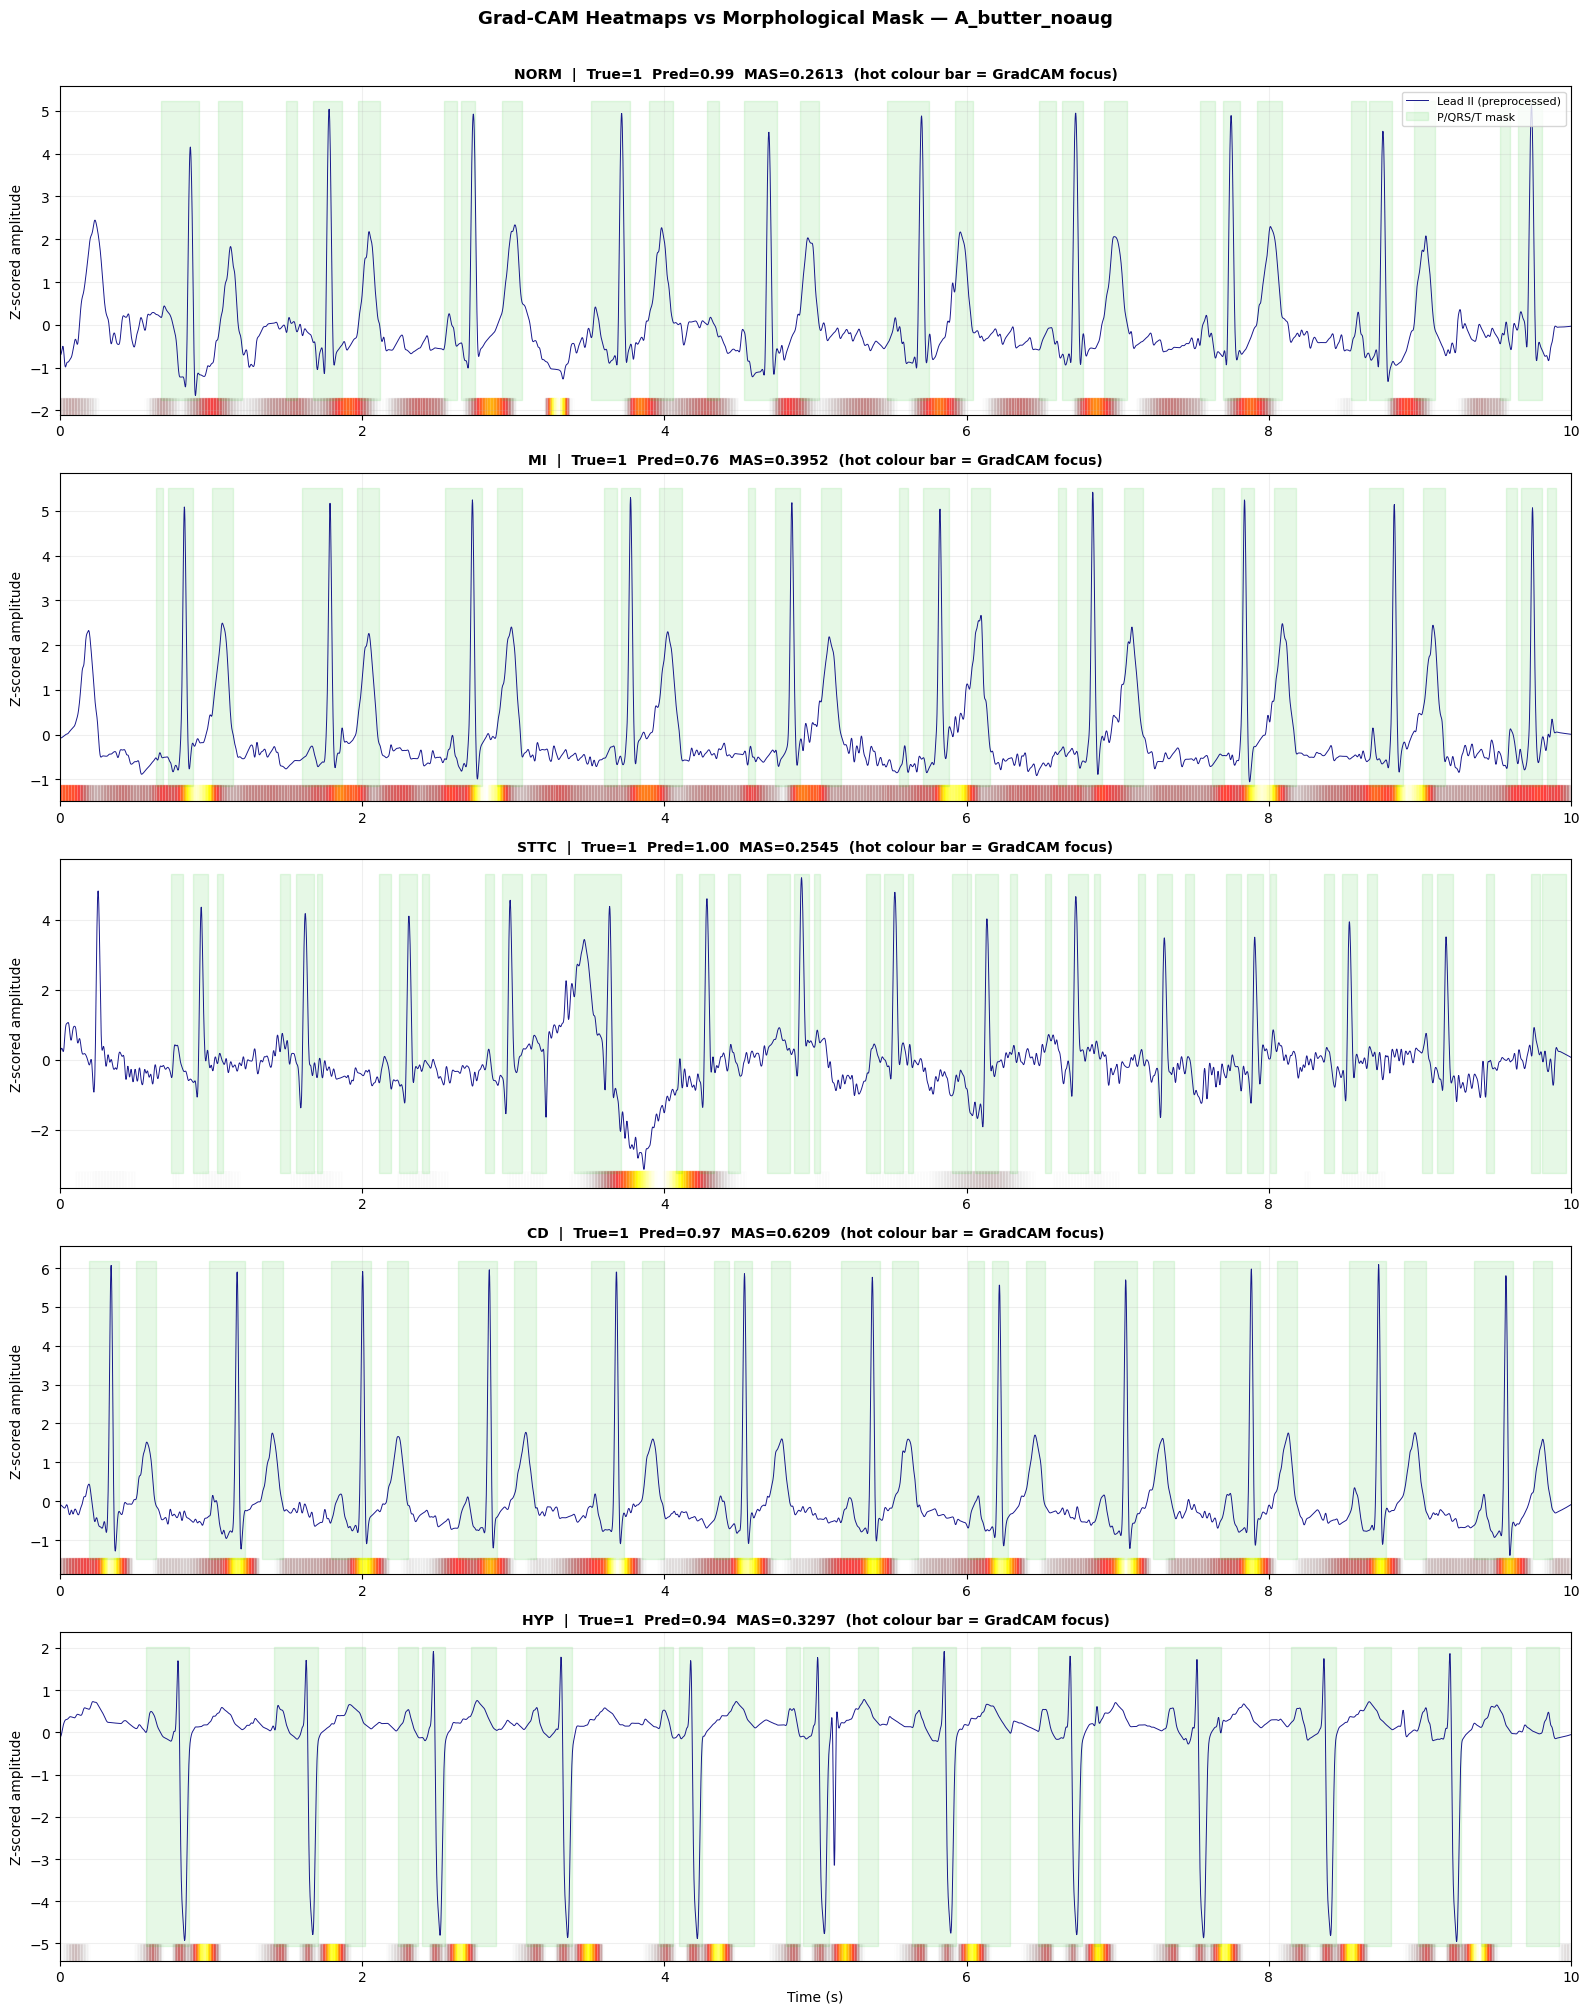


=== MAS Summary — A_butter_noaug ===
Class       MAS
----------------
NORM     0.2613
MI       0.3952
STTC     0.2545
CD       0.6209
HYP      0.3297
MEAN     0.3723
GradCAM hooks removed.

Grad-CAM — B_butter_lbwa
Selected test sample indices per class:
NORM  : test index 0
MI    : test index 5
STTC  : test index 14
CD    : test index 6
HYP   : test index 24


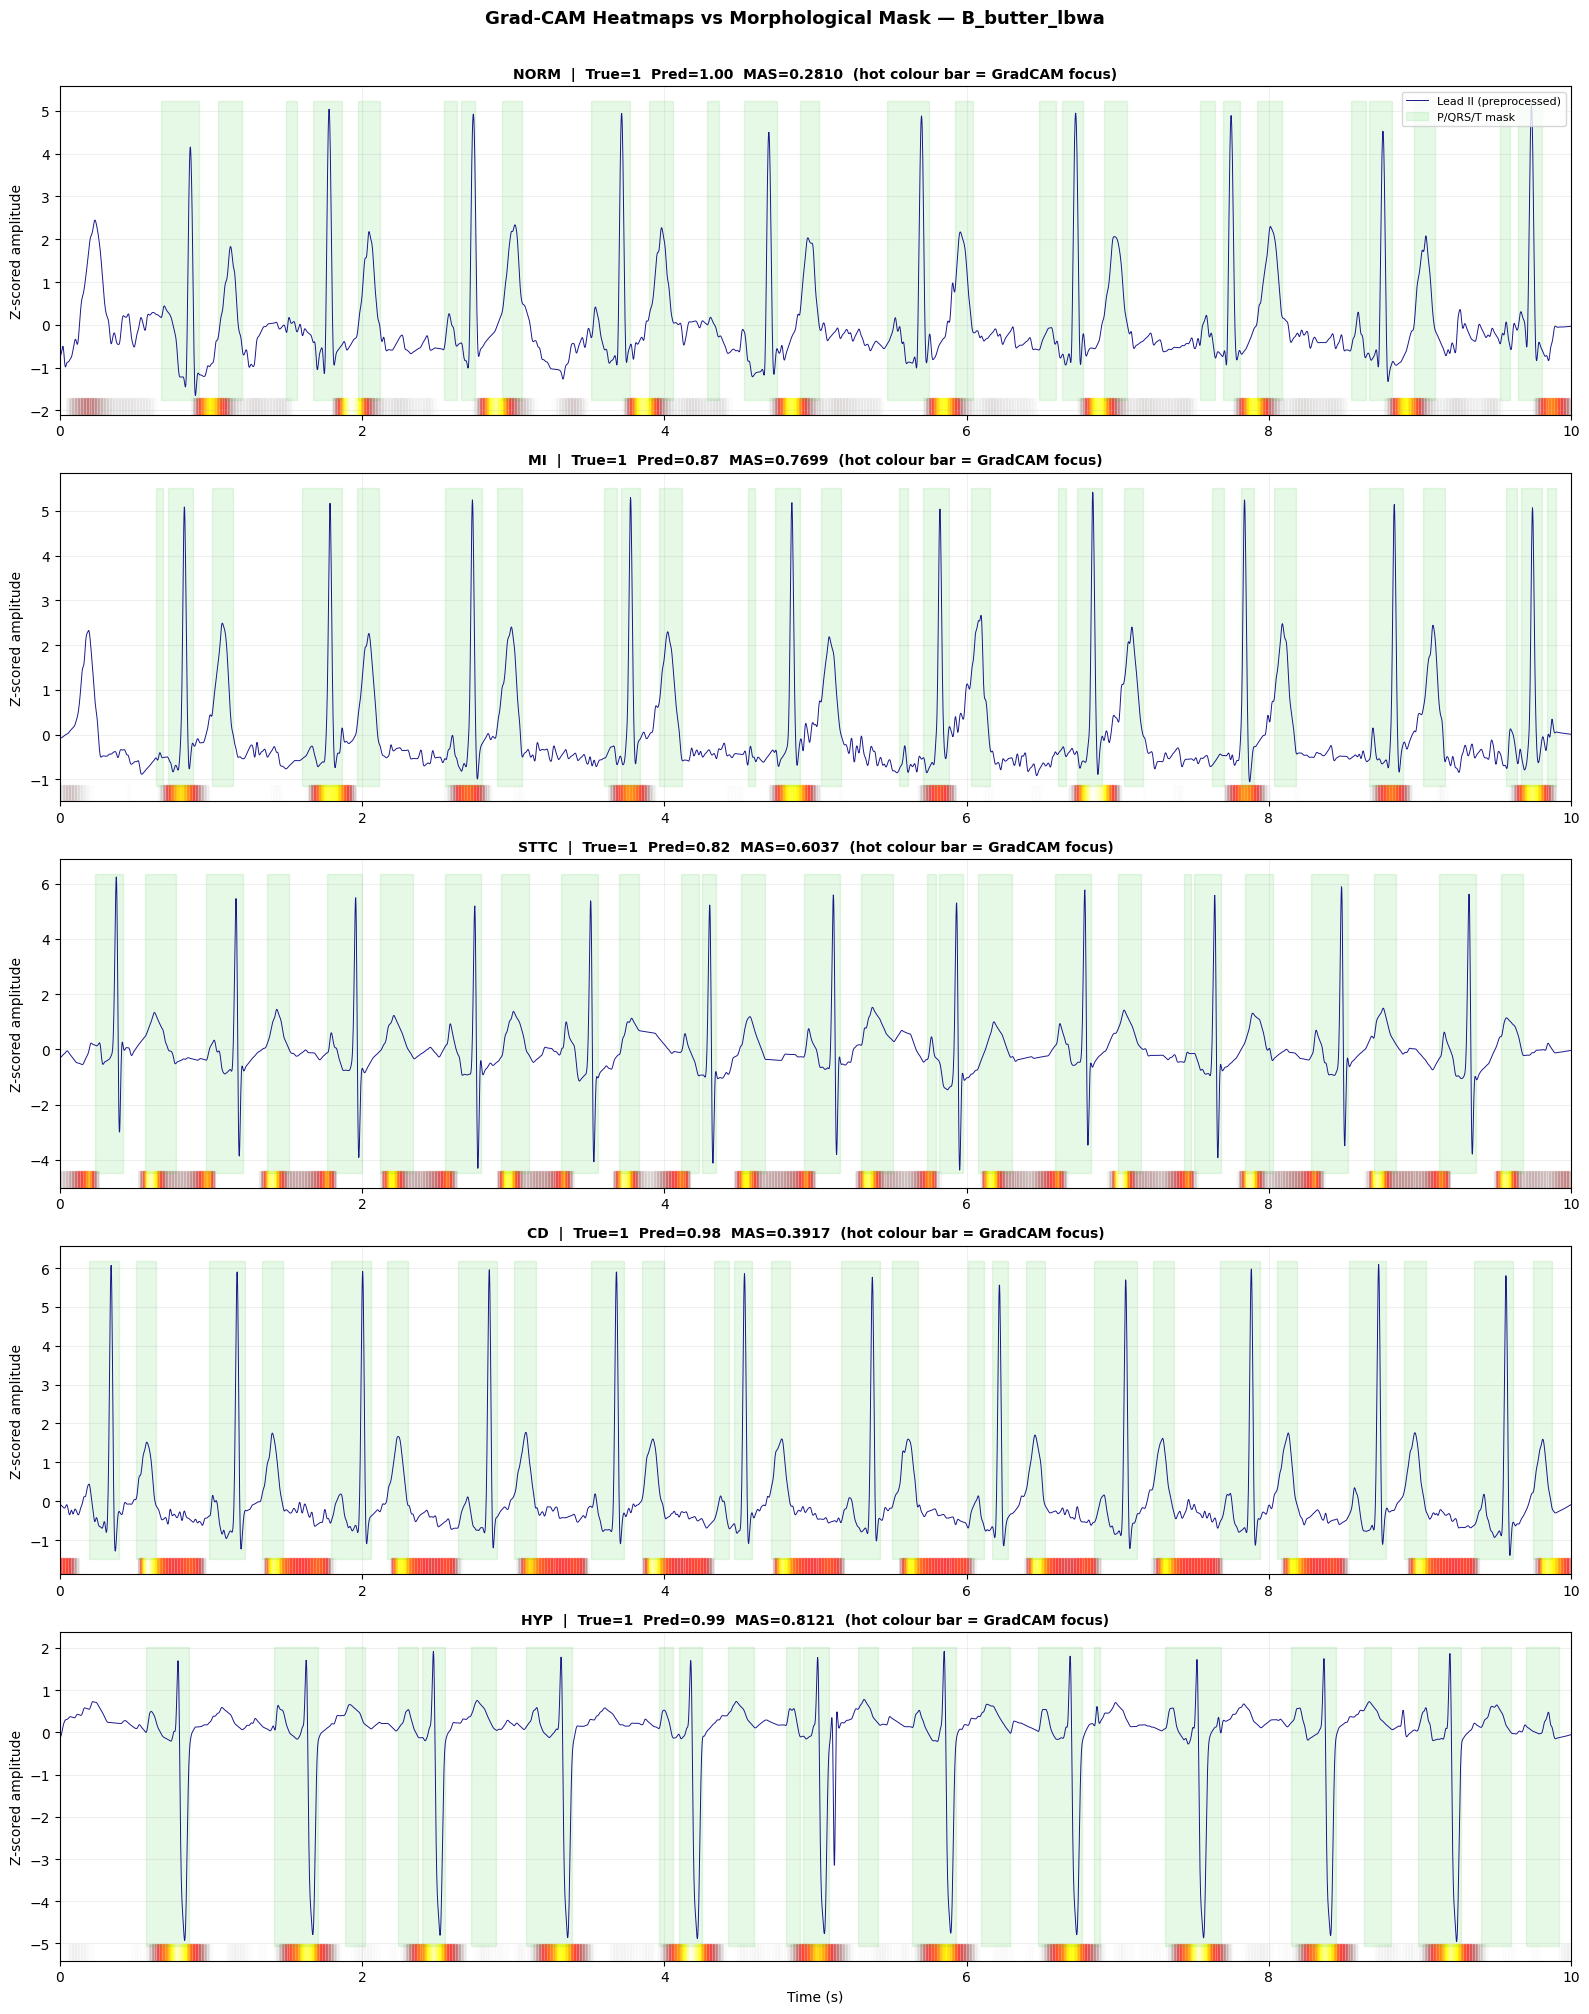


=== MAS Summary — B_butter_lbwa ===
Class       MAS
----------------
NORM     0.2810
MI       0.7699
STTC     0.6037
CD       0.3917
HYP      0.8121
MEAN     0.5717
GradCAM hooks removed.

Grad-CAM — C_swt_noaug
Selected test sample indices per class:
NORM  : test index 0
MI    : test index 5
STTC  : test index 14
CD    : test index 6
HYP   : test index 24


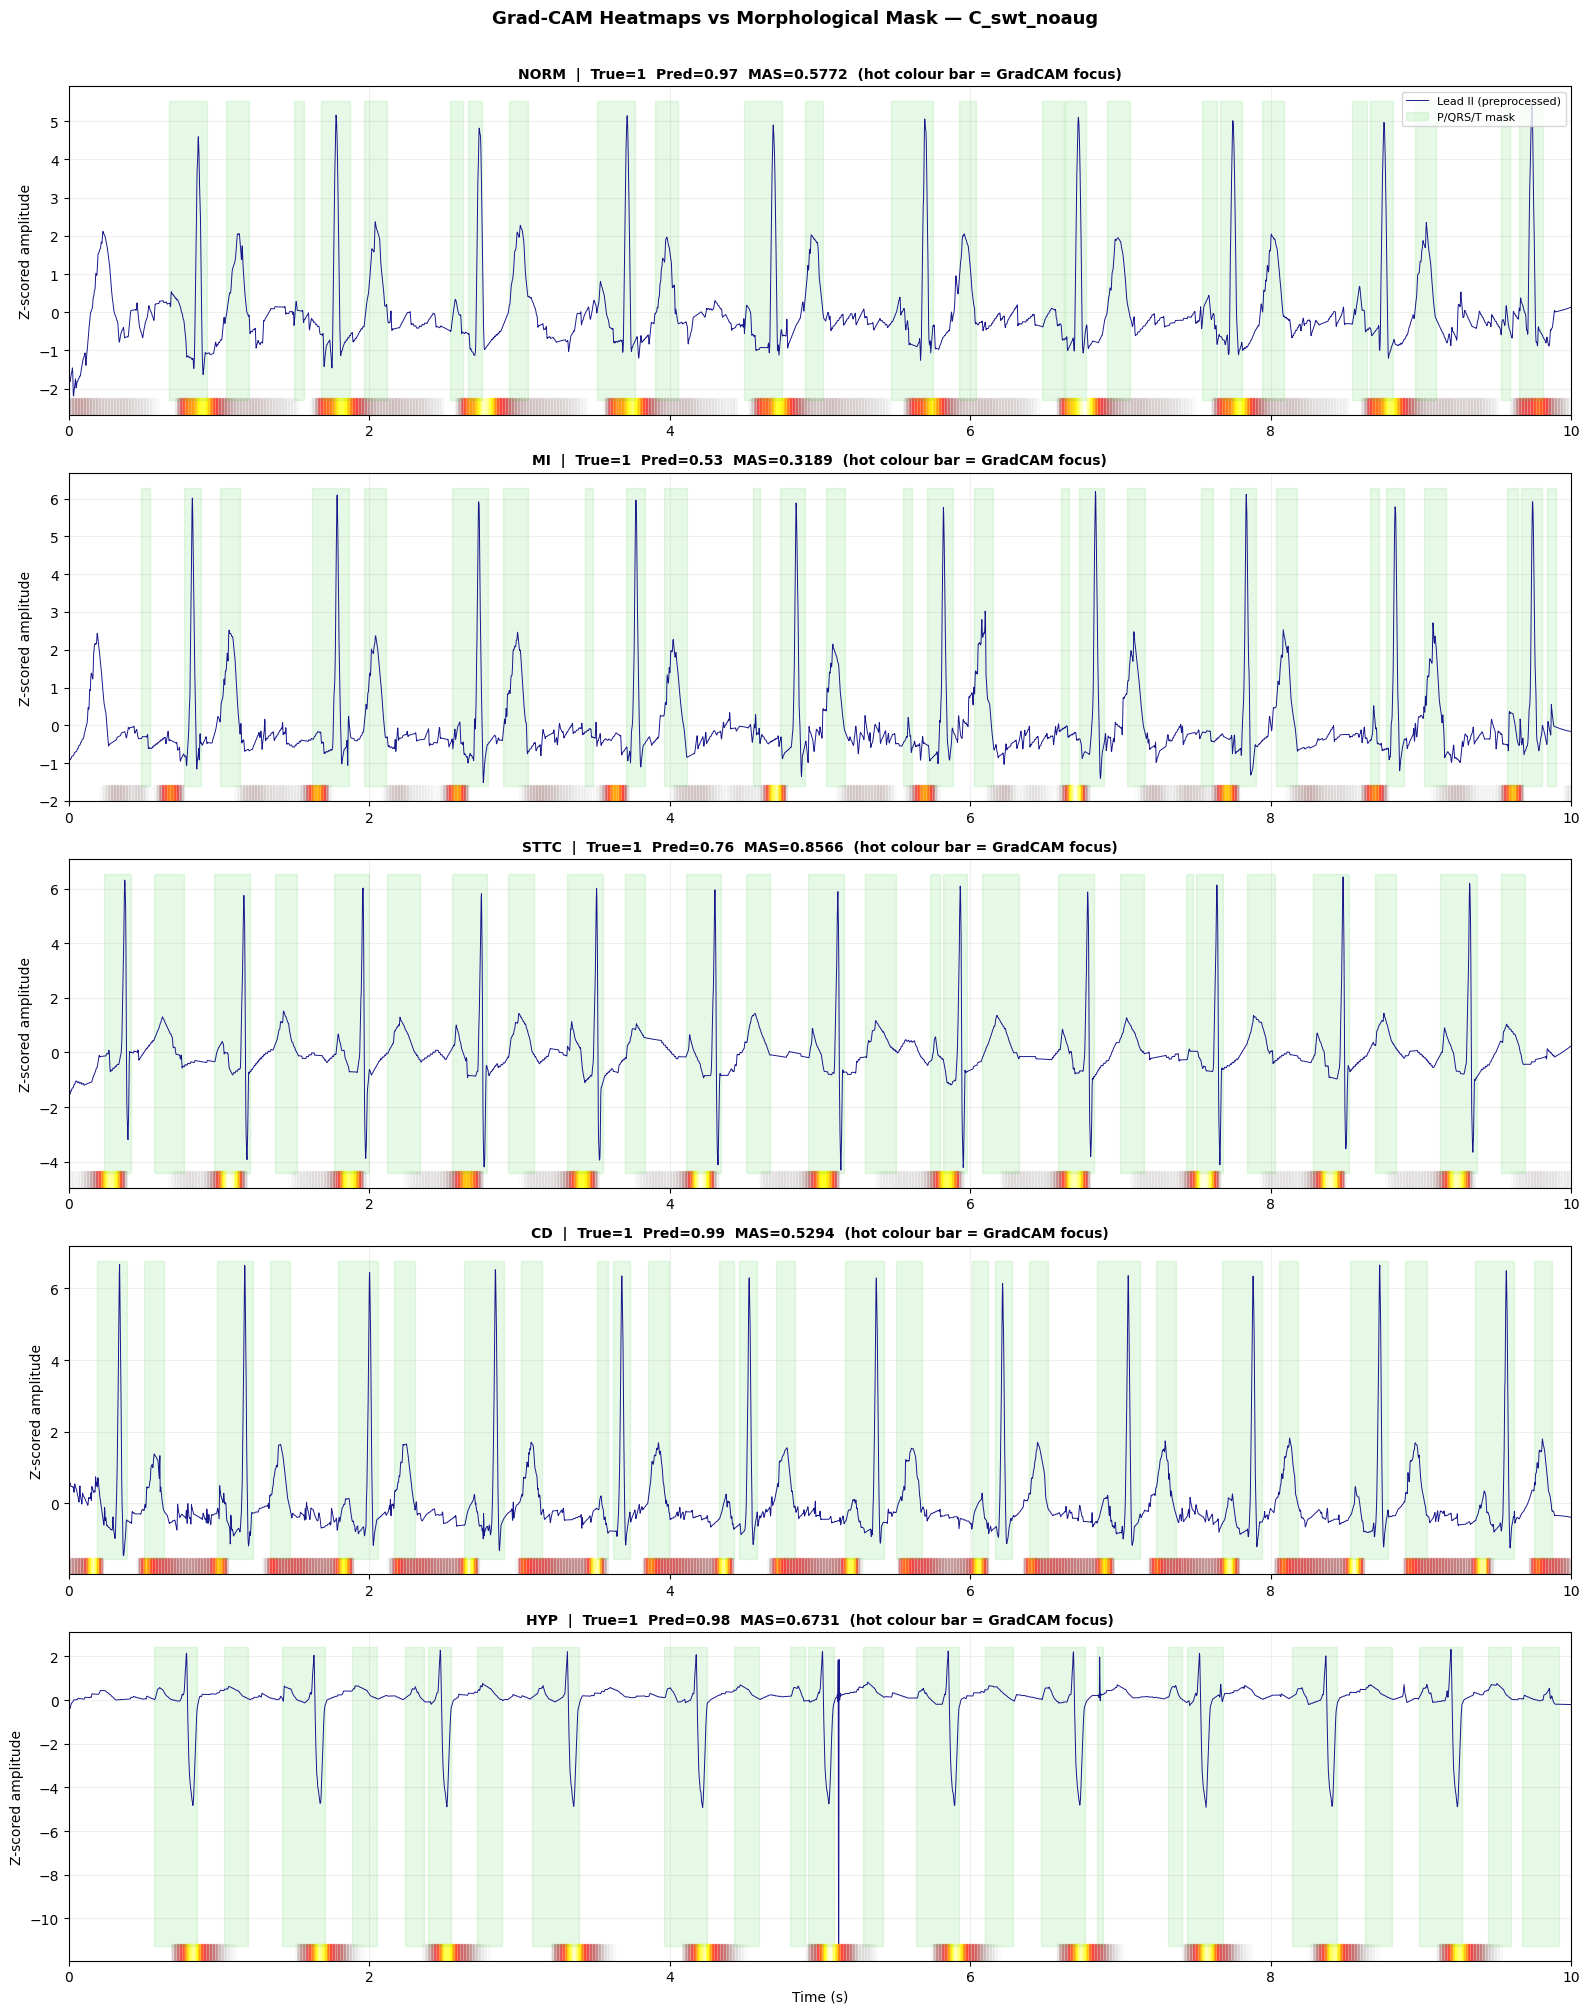


=== MAS Summary — C_swt_noaug ===
Class       MAS
----------------
NORM     0.5772
MI       0.3189
STTC     0.8566
CD       0.5294
HYP      0.6731
MEAN     0.5910
GradCAM hooks removed.

Grad-CAM — D_swt_lbwa
Selected test sample indices per class:
NORM  : test index 0
MI    : test index 5
STTC  : test index 19
CD    : test index 6
HYP   : test index 24


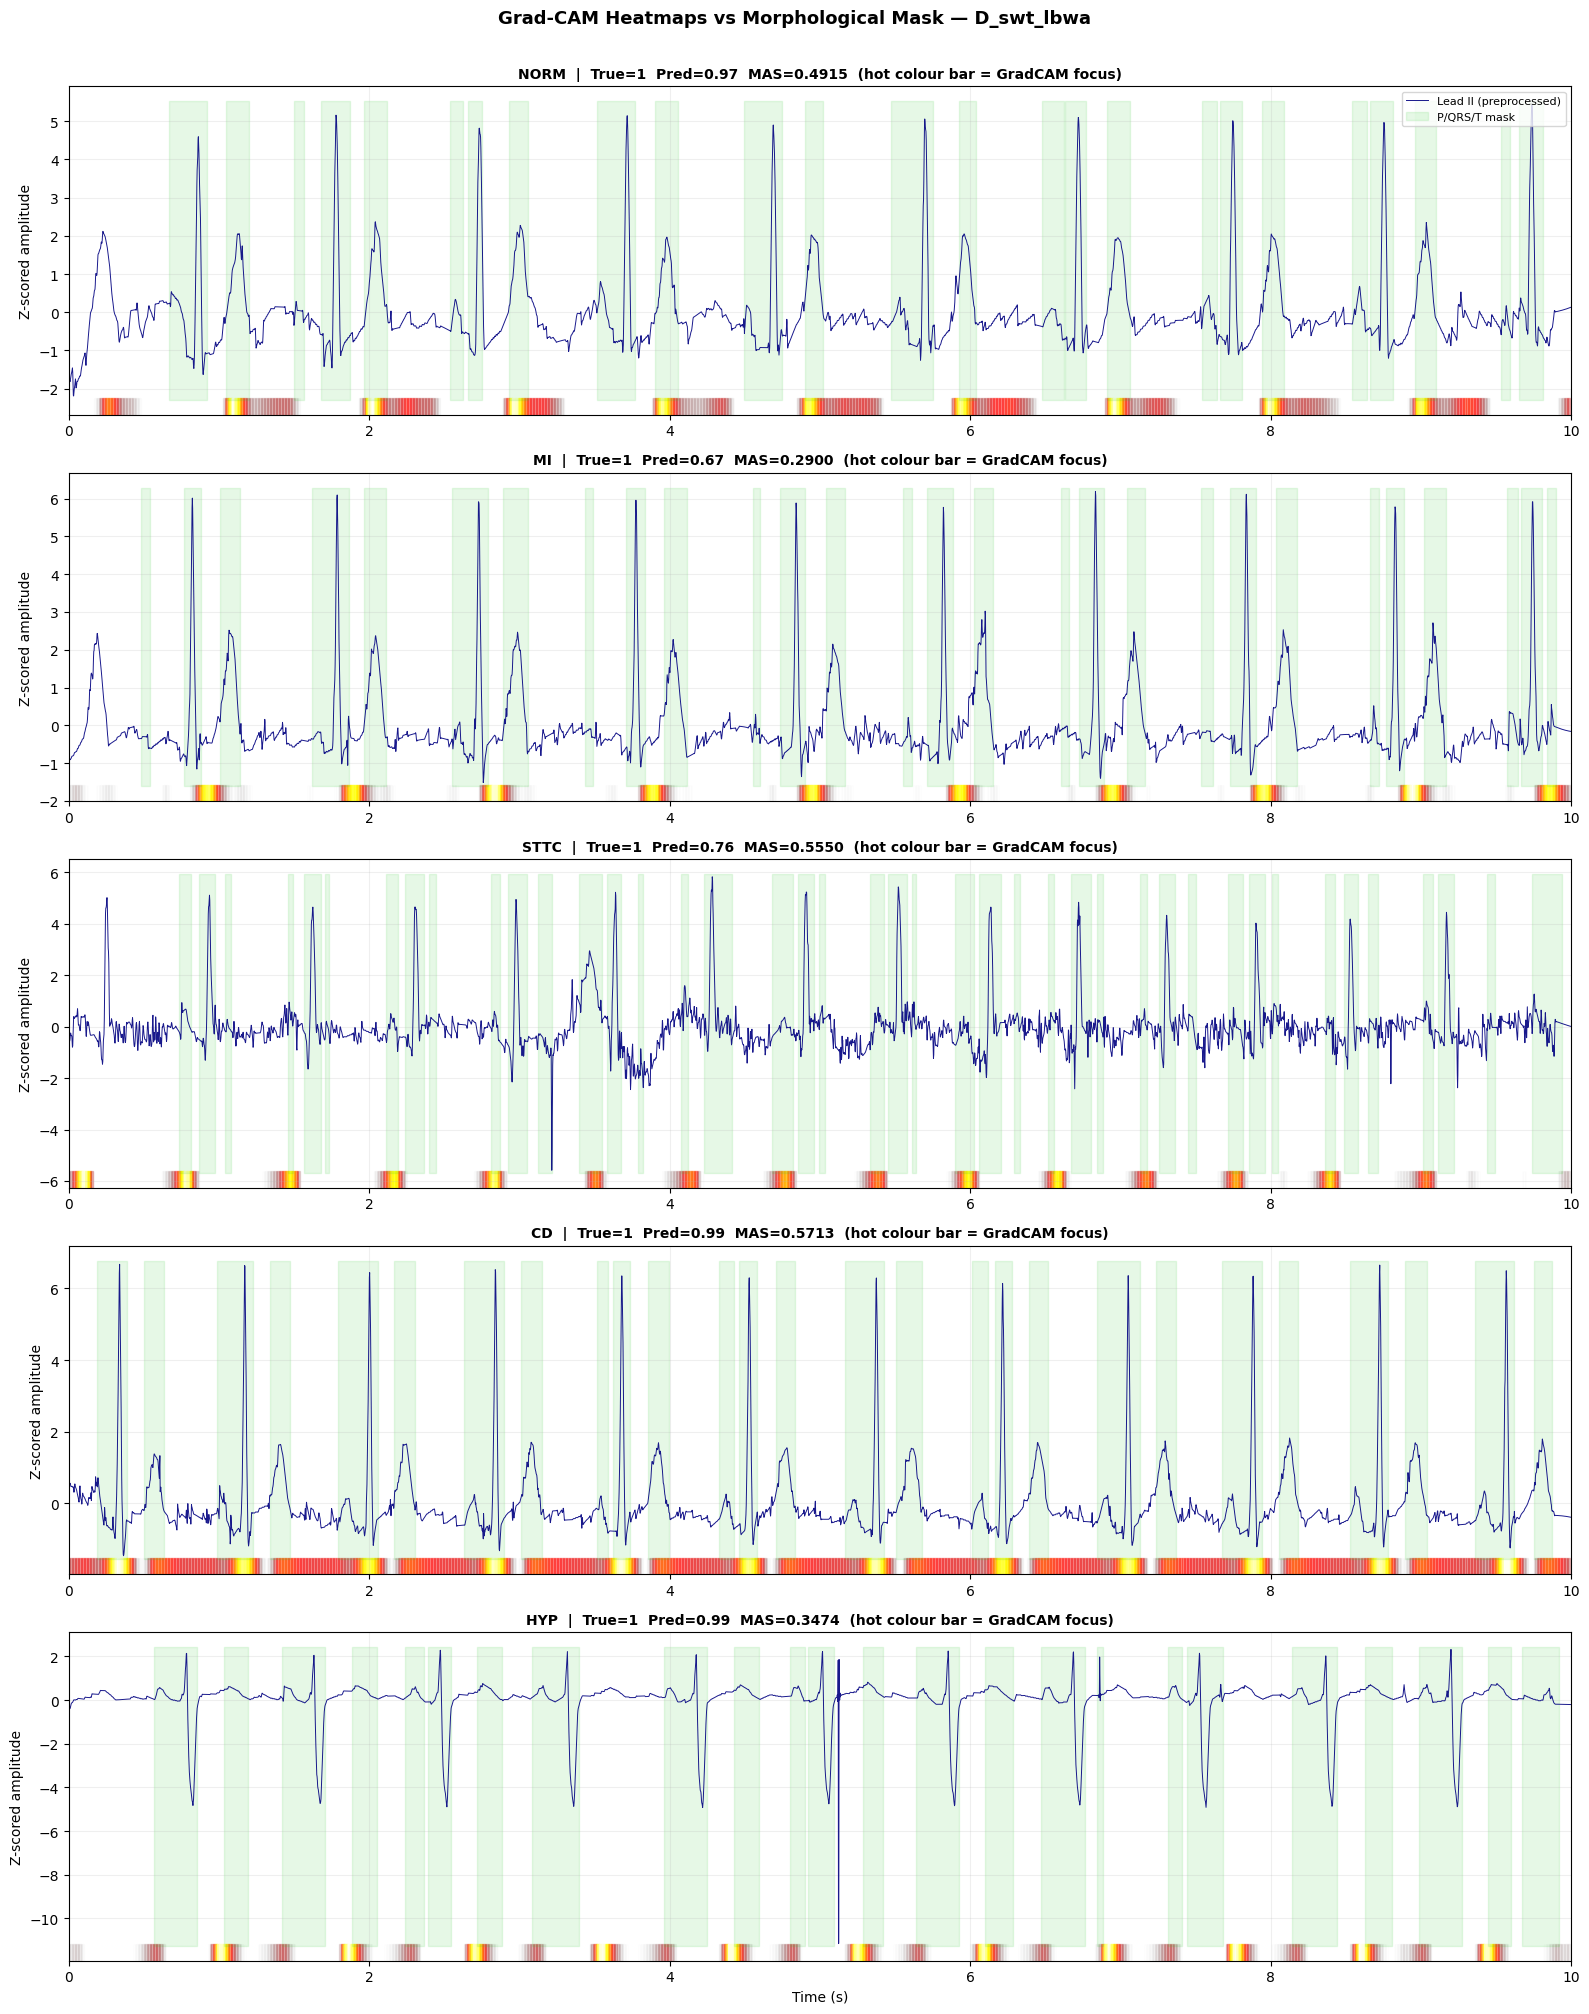


=== MAS Summary — D_swt_lbwa ===
Class       MAS
----------------
NORM     0.4915
MI       0.2900
STTC     0.5550
CD       0.5713
HYP      0.3474
MEAN     0.4510
GradCAM hooks removed.

Grad-CAM — E_raw_no_preprocess
Selected test sample indices per class:
NORM  : test index 0
MI    : test index 24
STTC  : test index 19
CD    : test index 6
HYP   : test index 24


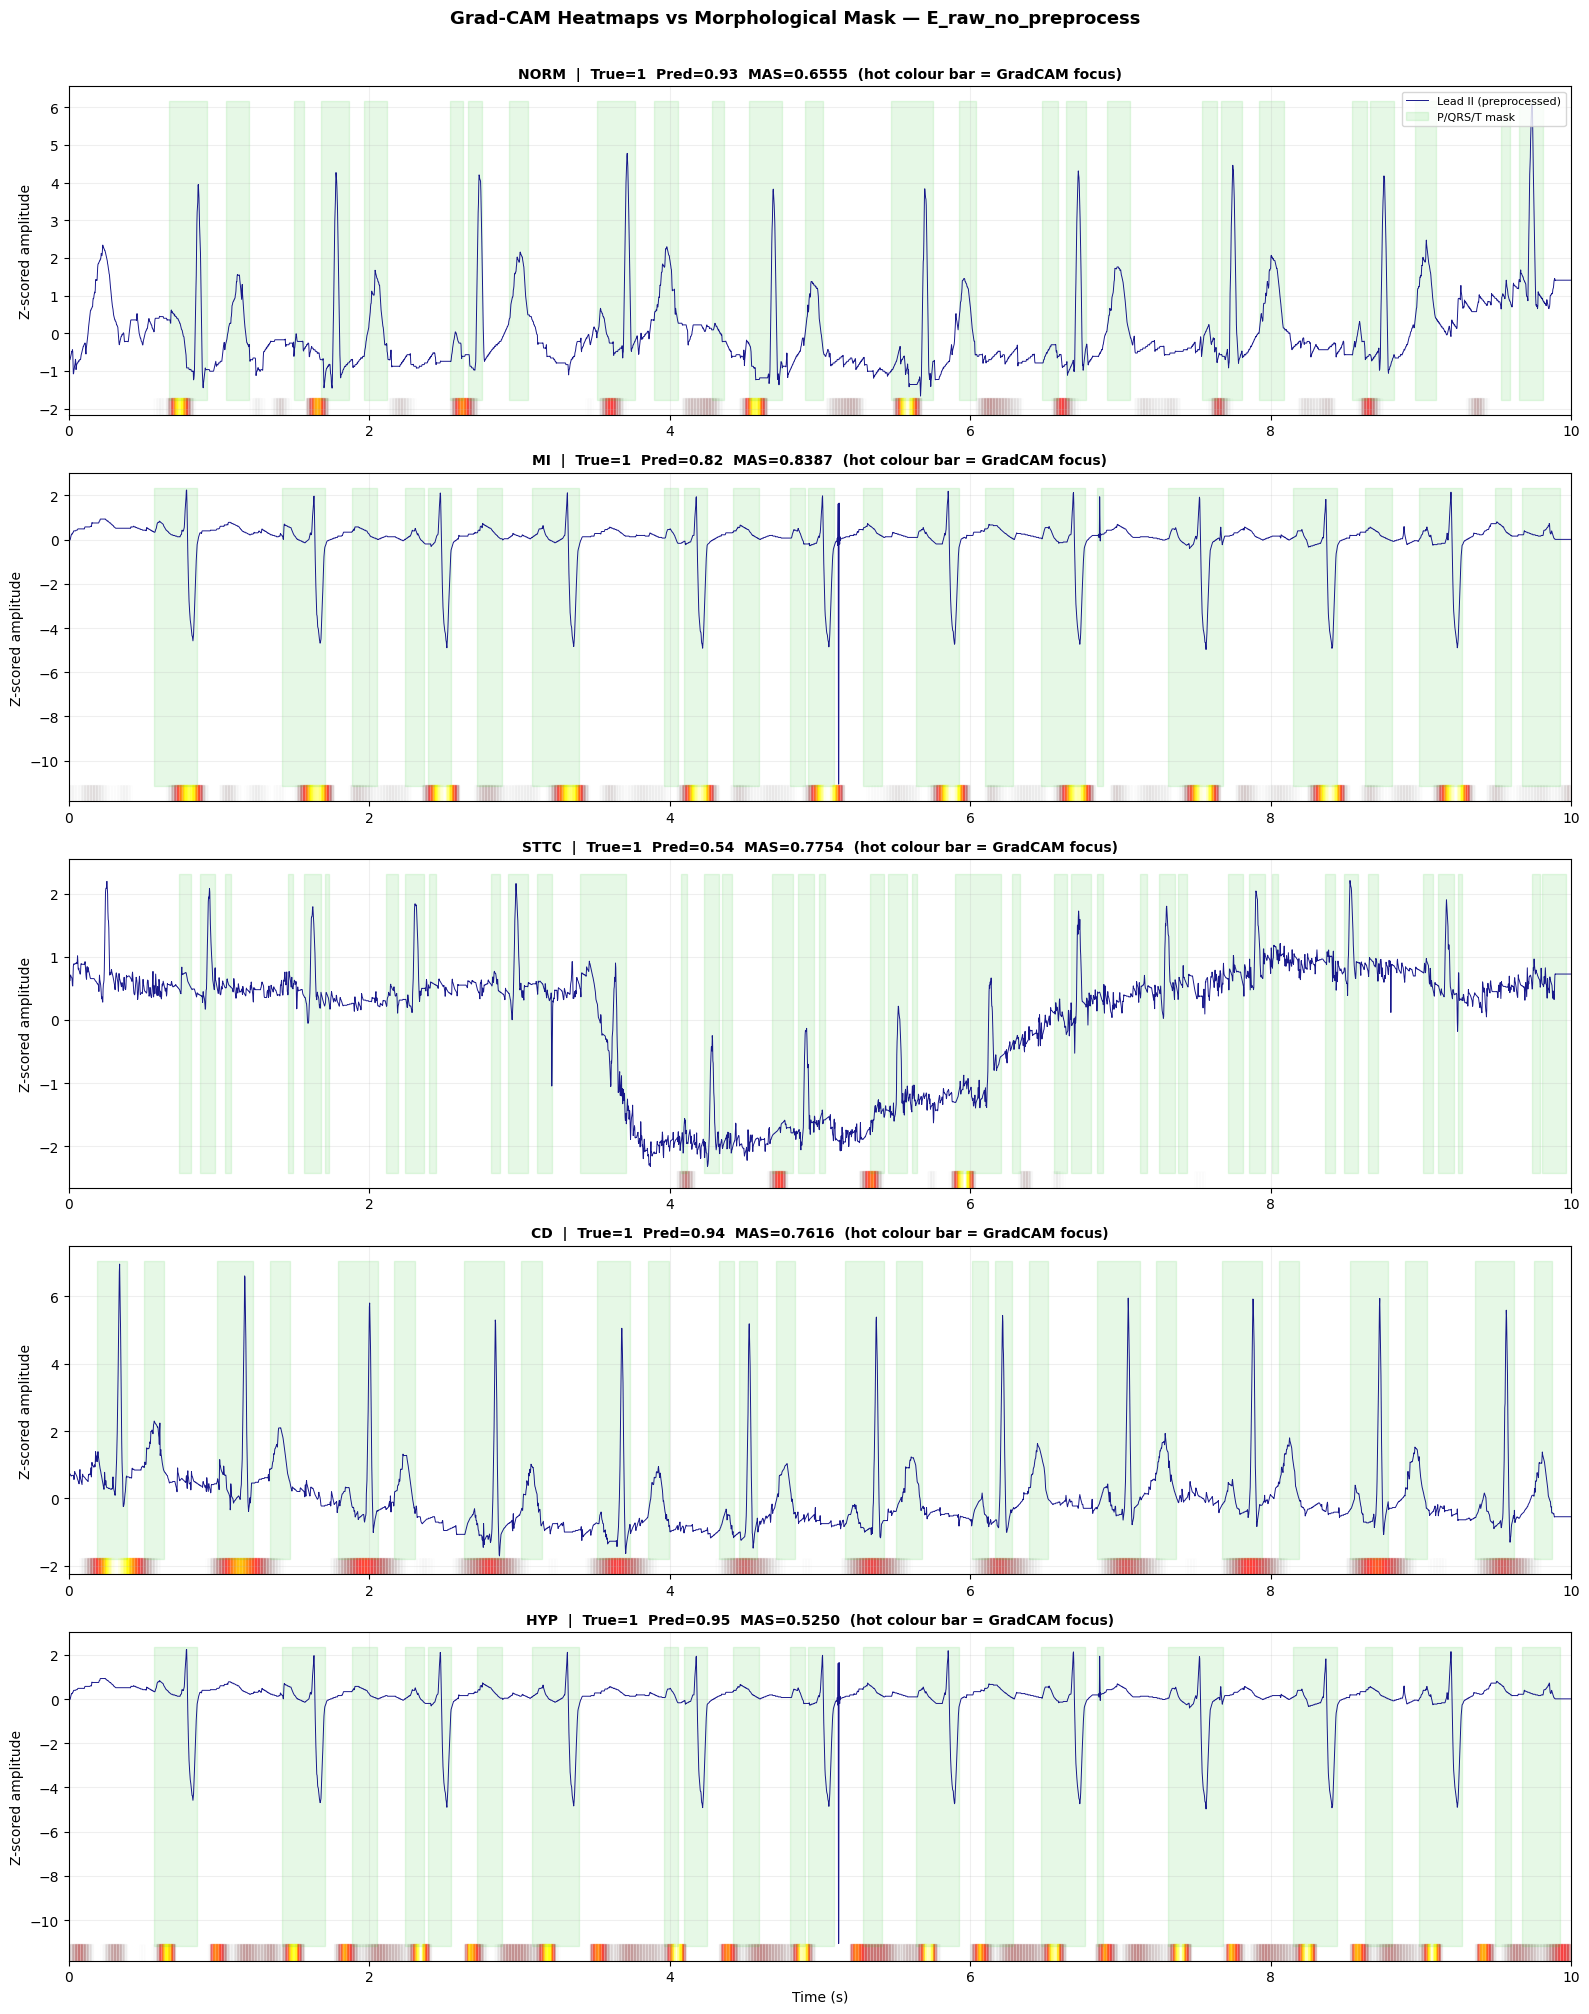


=== MAS Summary — E_raw_no_preprocess ===
Class       MAS
----------------
NORM     0.6555
MI       0.8387
STTC     0.7754
CD       0.7616
HYP      0.5250
MEAN     0.7112
GradCAM hooks removed.


In [19]:
def plot_gradcam_for_condition(condition_name):
    print(f"\n{'='*60}")
    print(f"Grad-CAM — {condition_name}")
    print(f"{'='*60}")

    # --- loading checkpoint ---
    ckpt_path=os.path.join(SAVE_PATH,'training_checkpoints',condition_name,'best_model.pt')
    ckpt=torch.load(ckpt_path, map_location=DEVICE)
    model=ResNet1D().to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # --- loading the test split ---
    test_data=torch.load(os.path.join(SAVE_PATH,condition_name,'test.pt'),map_location='cpu')
    X_test=test_data['X'].float()
    y_test=test_data['y'].float()
    M_test=test_data['M'].float()

    # --- getting the predictions on full test set to find the correct samples ---
    model.eval()
    all_probs=[]
    with torch.no_grad():
        for start in range(0,len(X_test),TRAIN_BATCH_SIZE):
            xb=X_test[start:start+TRAIN_BATCH_SIZE].to(DEVICE)
            all_probs.append(torch.sigmoid(model(xb)).cpu().numpy())
    test_preds=np.concatenate(all_probs, axis=0)
    test_labels=y_test.numpy()
    binary_preds=(test_preds>=PRED_THRESHOLD).astype(int)

    # --- picking one correctly predicted sample per class ---
    class_sample_idx={}
    for i,cls in enumerate(SUPERCLASSES):
        correct=np.where((test_labels[:,i]==1) & (binary_preds[:,i]==1))[0]
        if len(correct)==0:
            correct=np.where(test_labels[:,i]==1)[0]
        class_sample_idx[cls]=int(correct[0]) if len(correct)>0 else 0

    print("Selected test sample indices per class:")
    for cls, idx in class_sample_idx.items():
        print(f"{cls:<6}: test index {idx}")

    # --- attaching GradCAM ---
    gcam=GradCAM1D(model,model.get_gradcam_target_layer())

    # --- plotting ---
    fig,axes=plt.subplots(len(SUPERCLASSES),1,figsize=(16,4*len(SUPERCLASSES)))
    mas_scores={}

    for row_i,cls in enumerate(SUPERCLASSES):
        class_idx=SUPERCLASSES.index(cls)
        sample_i=class_sample_idx[cls]

        x_t=X_test[sample_i].unsqueeze(0).to(DEVICE)   # (1, 3, 5000)
        mask=M_test[sample_i].numpy()                    # (5000,)

        # GradCAM heatmap
        heatmap=gcam.compute(x_t,class_idx,output_length=SIGNAL_LEN)
        mas=compute_mas_from_gradcam(heatmap,mask,output_len=SIGNAL_LEN)
        mas_scores[cls]=mas

        # Lead II signal
        l2=X_test[sample_i][MORPH_LEAD].numpy()
        t=np.arange(SIGNAL_LEN)/FS

        ax=axes[row_i]
        ax.plot(t,l2,color='navy',lw=0.7,alpha=0.9,label='Lead II (preprocessed)')

        # Heatmap as coloured bar at bottom
        norm_hm=heatmap/(heatmap.max()+1e-10)
        cmap=cm.get_cmap('hot')
        for j in range(0, SIGNAL_LEN-5, 5):   # step=5 for speed
            c=cmap(float(norm_hm[j]))
            ax.axvspan(t[j],t[j+5],ymin=0.0,ymax=0.05,
                       color=c, alpha=float(norm_hm[j]))

        # Morphological mask overlay
        ax.fill_between(t,l2.min()-0.1,l2.max()+0.1,
                        where=mask.astype(bool),color='limegreen',alpha=0.12,
                        label='P/QRS/T mask')

        true_lbl =int(test_labels[sample_i,class_idx])
        pred_prob=float(test_preds[sample_i,class_idx])
        ax.set_title(
            f"{cls}  |  True={true_lbl}  Pred={pred_prob:.2f}  MAS={mas:.4f}"
            f"  (hot colour bar = GradCAM focus)",
            fontsize=10, fontweight='bold'
        )
        ax.set_ylabel('Z-scored amplitude')
        ax.set_xlim([0,10])
        ax.grid(True,alpha=0.2)
        if row_i==0:
            ax.legend(loc='upper right',fontsize=8)
        if row_i==len(SUPERCLASSES)-1:
            ax.set_xlabel('Time (s)')

    plt.suptitle(f'Grad-CAM Heatmaps vs Morphological Mask — {condition_name}',
                 fontsize=13, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.show()

    # --- MAS summary ---
    print(f"\n=== MAS Summary — {condition_name} ===")
    print(f"{'Class':<6} {'MAS':>8}")
    print("-" * 16)
    for cls, mas in mas_scores.items():
        print(f"{cls:<6} {mas:>8.4f}")
    print(f"{'MEAN':<6} {np.mean(list(mas_scores.values())):>8.4f}")

    gcam.remove_hooks()
    print("GradCAM hooks removed.")


# --- Running for all trained conditions ---
for cond_name in CONDITIONS_TO_TRAIN:
    plot_gradcam_for_condition(cond_name)

## 7. Final Ablation Report

This section turns the raw condition metrics into decision-ready summaries.

Outputs:
- Best condition per key metric (Macro-AUC, Macro-F1, MAS, MI AUC, HYP AUC).
- Composite-score leaderboard for forward recommendation.
- CSV export of the final report for external analysis.

In [20]:
if 'results_df' not in globals() or results_df.empty:
    raise RuntimeError("Run the multi-condition training cell first to build results_df.")

metric_specs = [
    ('test_macro_auc', 'Macro-AUC'),
    ('test_macro_f1', 'Macro-F1'),
    ('test_mean_mas', 'Mean MAS'),
    ('auc_MI', 'MI AUC'),
    ('auc_HYP', 'HYP AUC'),
]

# Ensure numeric columns
for col, _ in metric_specs:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

best_rows = []
for col, label in metric_specs:
    valid = results_df.dropna(subset=[col]).copy()
    if valid.empty:
        best_rows.append({
            'metric': label,
            'best_condition': 'N/A',
            'denoising': 'N/A',
            'augmentation': 'N/A',
            'value': np.nan,
        })
        continue

    best_idx = valid[col].idxmax()
    best_rows.append({
        'metric': label,
        'best_condition': valid.loc[best_idx, 'condition'],
        'denoising': valid.loc[best_idx, 'denoising'],
        'augmentation': valid.loc[best_idx, 'augmentation'],
        'value': float(valid.loc[best_idx, col]),
    })

ablation_report_df = pd.DataFrame(best_rows)

print("=== Final Ablation Report: Best Route per Metric ===")
display(ablation_report_df)

# Count wins per condition across key metrics
wins = (
    ablation_report_df['best_condition']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'condition', 'best_condition': 'metric_wins'})
)
wins.columns = ['condition', 'metric_wins']

# Composite score for forward recommendation
composite_metrics = ['test_macro_auc', 'test_macro_f1', 'test_mean_mas', 'auc_MI', 'auc_HYP']
composite_df = results_df[['condition', 'denoising', 'augmentation'] + composite_metrics].copy()

for c in composite_metrics:
    vals = composite_df[c].astype(float)
    vmin, vmax = vals.min(skipna=True), vals.max(skipna=True)
    if pd.isna(vmin) or pd.isna(vmax) or abs(vmax - vmin) < 1e-12:
        composite_df[c + '_norm'] = 0.5
    else:
        composite_df[c + '_norm'] = (vals - vmin) / (vmax - vmin)

norm_cols = [c + '_norm' for c in composite_metrics]
composite_df['composite_score'] = composite_df[norm_cols].mean(axis=1)
composite_df = composite_df.merge(wins, on='condition', how='left')
composite_df['metric_wins'] = composite_df['metric_wins'].fillna(0).astype(int)

best_overall_idx = composite_df['composite_score'].idxmax()
best_overall = composite_df.loc[best_overall_idx]

print("\n=== Forward Recommendation ===")
print(f"Recommended route: {best_overall['condition']}")
print(f"  Denoising    : {best_overall['denoising']}")
print(f"  Augmentation : {best_overall['augmentation']}")
print(f"  Composite score (0-1): {best_overall['composite_score']:.4f}")
print(f"  Metric wins         : {best_overall['metric_wins']}")

# print("\nWhy this route:")
# print("1. It balances classification quality (Macro-AUC, Macro-F1) with medical grounding (MAS).")
# print("2. It is also checked on MI and HYP class-specific AUC, aligning with your focus classes.")

# print("\nFuture improvement directions:")
# print("1. Tune LBWA strength (AUG_ALPHA, AUG_AMP_STD) per class, especially for HYP and MI.")
# print("2. Add a MAS-aware validation criterion (e.g., weighted objective: AUC + lambda * MAS).")
# print("3. Extend Grad-CAM analysis to class-conditioned sample sets to inspect failure modes.")
# print("4. Try lightweight test-time augmentation for robustness without retraining.")

final_report_path = os.path.join(SAVE_PATH, 'final_ablation_report.csv')
ablation_report_df.to_csv(final_report_path, index=False)
print(f"\nSaved final ablation report to: {final_report_path}")

print("\nComposite leaderboard:")
display(
    composite_df[[
        'condition', 'denoising', 'augmentation', 'metric_wins',
        'composite_score', 'test_macro_auc', 'test_macro_f1', 'test_mean_mas', 'auc_MI', 'auc_HYP'
    ]].sort_values('composite_score', ascending=False).reset_index(drop=True)
)

=== Final Ablation Report: Best Route per Metric ===


,metric,best_condition,denoising,augmentation,value
0,Macro-AUC,E_raw_no_preprocess,Raw + Z-score (no filter),None,0.898690
1,Macro-F1,A_butter_noaug,Butterworth,None,0.695210
2,Mean MAS,E_raw_no_preprocess,Raw + Z-score (no filter),None,0.665766
3,MI AUC,C_swt_noaug,Selective SWT,None,0.912414
4,HYP AUC,E_raw_no_preprocess,Raw + Z-score (no filter),None,0.818287



=== Forward Recommendation ===
Recommended route: E_raw_no_preprocess
  Denoising    : Raw + Z-score (no filter)
  Augmentation : None
  Composite score (0-1): 0.9627
  Metric wins         : 3

Saved final ablation report to: /kaggle/working/final_ablation_report.csv

Composite leaderboard:


,condition,denoising,augmentation,metric_wins,composite_score,test_macro_auc,test_macro_f1,test_mean_mas,auc_MI,auc_HYP
0,E_raw_no_preprocess,Raw + Z-score (no filter),None,3,0.962747,0.898690,0.694938,0.665766,0.909462,0.818287
1,C_swt_noaug,Selective SWT,None,1,0.685903,0.898417,0.683951,0.620108,0.912414,0.808827
2,A_butter_noaug,Butterworth,None,1,0.608827,0.897531,0.695210,0.478147,0.905603,0.814107
3,B_butter_lbwa,Butterworth,LBWA,0,0.242958,0.894636,0.672224,0.455921,0.895912,0.814129
4,D_swt_lbwa,Selective SWT,LBWA,0,0.201889,0.893096,0.658187,0.535126,0.901351,0.811688
